# Credit Card Fraud Detection

### Libraries and Dataset Import
We import the required libraries and load the training dataset. A quick look at the first rows gives an overview of the available features.

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from sklearn.pipeline import Pipeline
from sklearn.linear_model import LogisticRegression
from sklearn.preprocessing import OneHotEncoder, StandardScaler
from sklearn.compose import ColumnTransformer
from lightgbm import LGBMClassifier, early_stopping, log_evaluation
from sklearn.model_selection import train_test_split
from sklearn.metrics import (classification_report, roc_auc_score, average_precision_score,
                              ConfusionMatrixDisplay, RocCurveDisplay, PrecisionRecallDisplay,
                              precision_recall_curve, f1_score)
import torch
import torch.nn.functional as F
from torch import nn, optim
from torch.utils.data import DataLoader, TensorDataset

In [2]:
df = pd.read_csv("archive/fraudTrain.csv", index_col="Unnamed: 0")
df.head()

,trans_date_trans_time,cc_num,merchant,category,amt,first,last,gender,street,city,...,lat,long,city_pop,job,dob,trans_num,unix_time,merch_lat,merch_long,is_fraud
0,2019-01-01 00:00:18,2703186189652095,"fraud_Rippin, Kub and Mann",misc_net,4.97,Jennifer,Banks,F,561 Perry Cove,Moravian Falls,...,36.0788,-81.1781,3495,"Psychologist, counselling",1988-03-09,0b242abb623afc578575680df30655b9,1325376018,36.011293,-82.048315,0
1,2019-01-01 00:00:44,630423337322,"fraud_Heller, Gutmann and Zieme",grocery_pos,107.23,Stephanie,Gill,F,43039 Riley Greens Suite 393,Orient,...,48.8878,-118.2105,149,Special educational needs teacher,1978-06-21,1f76529f8574734946361c461b024d99,1325376044,49.159047,-118.186462,0
2,2019-01-01 00:00:51,38859492057661,fraud_Lind-Buckridge,entertainment,220.11,Edward,Sanchez,M,594 White Dale Suite 530,Malad City,...,42.1808,-112.2620,4154,Nature conservation officer,1962-01-19,a1a22d70485983eac12b5b88dad1cf95,1325376051,43.150704,-112.154481,0
3,2019-01-01 00:01:16,3534093764340240,"fraud_Kutch, Hermiston and Farrell",gas_transport,45.00,Jeremy,White,M,9443 Cynthia Court Apt. 038,Boulder,...,46.2306,-112.1138,1939,Patent attorney,1967-01-12,6b849c168bdad6f867558c3793159a81,1325376076,47.034331,-112.561071,0
4,2019-01-01 00:03:06,375534208663984,fraud_Keeling-Crist,misc_pos,41.96,Tyler,Garcia,M,408 Bradley Rest,Doe Hill,...,38.4207,-79.4629,99,Dance movement psychotherapist,1986-03-28,a41d7549acf90789359a9aa5346dcb46,1325376186,38.674999,-78.632459,0


## Exploratory Data Analysis

We begin by familiarizing ourselves with the dataset: inspecting its shape and checking for missing or duplicate values. We also use `info()` to verify the data type of each column.

In [3]:
print(f"Dataset size: {df.shape}")
print(f"Missing values: {df.isna().sum().sum()}")
print(f"Duplicate values: {df.duplicated().sum()}")

Dataset size: (1296675, 22)
Missing values: 0
Duplicate values: 0


In [4]:
df.info()

<class 'pandas.core.frame.DataFrame'>
Index: 1296675 entries, 0 to 1296674
Data columns (total 22 columns):
 #   Column                 Non-Null Count    Dtype  
---  ------                 --------------    -----  
 0   trans_date_trans_time  1296675 non-null  object 
 1   cc_num                 1296675 non-null  int64  
 2   merchant               1296675 non-null  object 
 3   category               1296675 non-null  object 
 4   amt                    1296675 non-null  float64
 5   first                  1296675 non-null  object 
 6   last                   1296675 non-null  object 
 7   gender                 1296675 non-null  object 
 8   street                 1296675 non-null  object 
 9   city                   1296675 non-null  object 
 10  state                  1296675 non-null  object 
 11  zip                    1296675 non-null  int64  
 12  lat                    1296675 non-null  float64
 13  long                   1296675 non-null  float64
 14  city_pop               

The dataset contains no missing or duplicate values. Among the 22 features, all data types are correctly inferred except for the two temporal columns `trans_date_trans_time` and `dob`, which must be converted to datetime before any further processing.

In [5]:
df["trans_date_trans_time"]=pd.to_datetime(df["trans_date_trans_time"])
df["dob"]=pd.to_datetime(df["dob"])

We begin the EDA by examining the target variable `is_fraud` to assess the distribution of fraudulent transactions.

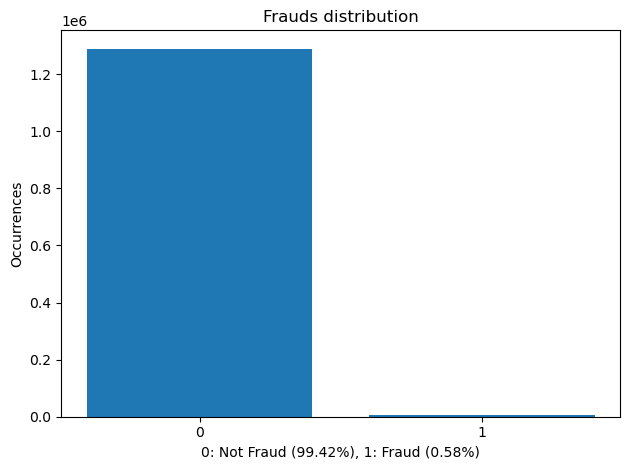

In [6]:
frauds=df["is_fraud"].value_counts()
fig,ax=plt.subplots()
ax.bar(frauds.index,frauds.values)
ax.set_xticks(frauds.index)
ax.set_title("Frauds distribution")
ax.set_xlabel(f"0: Not Fraud ({round(frauds[0]/frauds.sum()*100,2)}%), 1: Fraud ({round(frauds[1]/frauds.sum()*100,2)}%)")
ax.set_ylabel("Occurrences")

plt.tight_layout()
plt.show()

As expected, fraudulent transactions represent a negligible fraction of the dataset (~0.58%). This severe class imbalance means we are not dealing with a standard binary classification problem, but rather an anomaly detection task. We proceed by inspecting `trans_date_trans_time` to identify any temporal patterns in fraudulent activity.

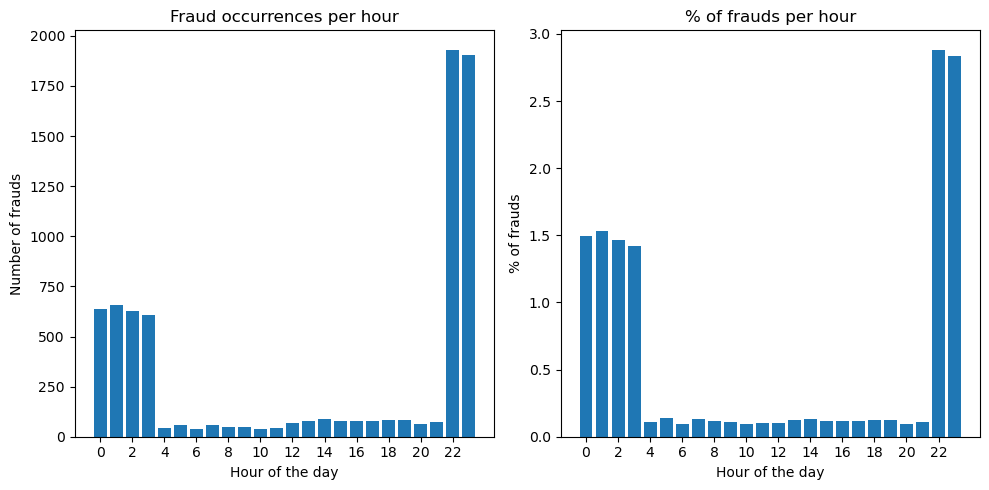

In [7]:
trans_hour=df["trans_date_trans_time"].dt.hour
fraud_hour=df["trans_date_trans_time"][df["is_fraud"]==1].dt.hour
trans_hour_counts=trans_hour.value_counts().sort_index()
fraud_hour_counts=fraud_hour.value_counts().sort_index()
perc_frauds=fraud_hour_counts/trans_hour_counts*100

fig,ax=plt.subplots(ncols=2, figsize=(10,5))
ax[0].bar(np.arange(24),fraud_hour_counts)
ax[0].set_xticks(np.arange(0,24,2))
ax[0].set_xlabel("Hour of the day")
ax[0].set_ylabel("Number of frauds")
ax[0].set_title("Fraud occurrences per hour")

ax[1].bar(np.arange(24),perc_frauds)
ax[1].set_xticks(np.arange(0,24,2))
ax[1].set_xlabel("Hour of the day")
ax[1].set_ylabel("% of frauds")
ax[1].set_title("% of frauds per hour")

plt.tight_layout()
plt.show()


The first important signal emerges clearly: fraud is strongly concentrated between 10 PM and 3 AM. This holds both in absolute count and as a percentage of total transactions per hour, ruling out any confound from varying transaction volumes throughout the day.

We further decompose the temporal dimension to check whether the day of the week, the day of the month, and the month of the year carry additional signal.

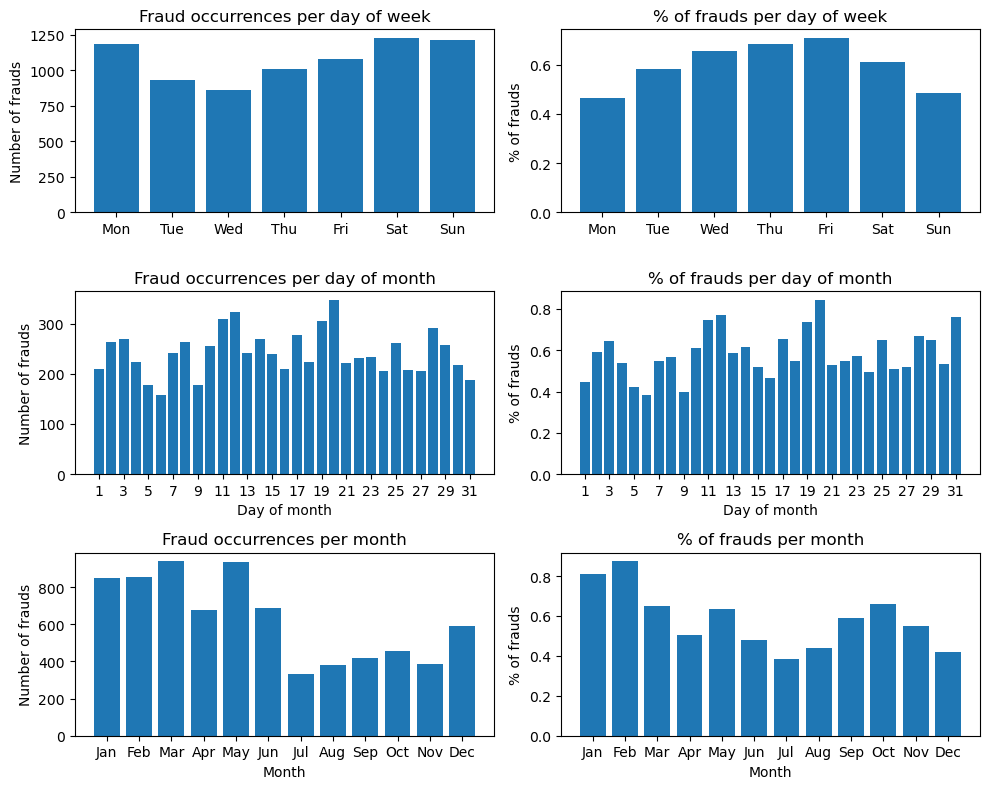

In [8]:
fig, ax = plt.subplots(nrows=3, ncols=2,figsize=(10,8))

trans_dow = df["trans_date_trans_time"].dt.dayofweek
fraud_dow = df["trans_date_trans_time"][df["is_fraud"]==1].dt.dayofweek
trans_dow_counts = trans_dow.value_counts().sort_index()
fraud_dow_counts = fraud_dow.value_counts().sort_index()
perc_frauds_dow = (fraud_dow_counts / trans_dow_counts) * 100

dow = ['Mon', 'Tue', 'Wed', 'Thu', 'Fri', 'Sat', 'Sun']

ax[0, 0].bar(trans_dow_counts.index, fraud_dow_counts)
ax[0, 0].set_xticks(range(7))
ax[0, 0].set_xticklabels(dow)
ax[0, 0].set_ylabel("Number of frauds")
ax[0, 0].set_title("Fraud occurrences per day of week")

ax[0, 1].bar(trans_dow_counts.index, perc_frauds_dow)
ax[0, 1].set_xticks(range(7))
ax[0, 1].set_xticklabels(dow)
ax[0, 1].set_ylabel("% of frauds")
ax[0, 1].set_title("% of frauds per day of week")

trans_dom = df["trans_date_trans_time"].dt.day
fraud_dom = df["trans_date_trans_time"][df["is_fraud"]==1].dt.day
trans_dom_counts = trans_dom.value_counts().sort_index()
fraud_dom_counts = fraud_dom.value_counts().sort_index()
perc_frauds_dom = (fraud_dom_counts / trans_dom_counts) * 100

ax[1, 0].bar(trans_dom_counts.index, fraud_dom_counts)
ax[1, 0].set_xticks(range(1, 32, 2))
ax[1, 0].set_xlabel("Day of month")
ax[1, 0].set_ylabel("Number of frauds")
ax[1, 0].set_title("Fraud occurrences per day of month")

ax[1, 1].bar(trans_dom_counts.index, perc_frauds_dom)
ax[1, 1].set_xticks(range(1, 32, 2))
ax[1, 1].set_xlabel("Day of month")
ax[1, 1].set_ylabel("% of frauds")
ax[1, 1].set_title("% of frauds per day of month")

trans_month = df["trans_date_trans_time"].dt.month
fraud_month = df["trans_date_trans_time"][df["is_fraud"] == 1].dt.month
trans_month_counts = trans_month.value_counts().sort_index()
fraud_month_counts = fraud_month.value_counts().sort_index()
perc_frauds_month = (fraud_month_counts / trans_month_counts) * 100

months = ['Jan', 'Feb', 'Mar', 'Apr', 'May', 'Jun',
          'Jul', 'Aug', 'Sep', 'Oct', 'Nov', 'Dec']


ax[2,0].bar(fraud_month_counts.index, fraud_month_counts.values)
ax[2,0].set_xticks(range(1, 13))
ax[2,0].set_xticklabels(months)
ax[2,0].set_xlabel("Month")
ax[2,0].set_ylabel("Number of frauds")
ax[2,0].set_title("Fraud occurrences per month")

ax[2,1].bar(perc_frauds_month.index, perc_frauds_month.values)
ax[2,1].set_xticks(range(1, 13))
ax[2,1].set_xticklabels(months)
ax[2,1].set_xlabel("Month")
ax[2,1].set_ylabel("% of frauds")
ax[2,1].set_title("% of frauds per month")

plt.tight_layout()
plt.show()

Broadening the temporal granularity yields no additional signal. Neither the day of the week, the day of the month, nor the month of the year show a consistent pattern in the fraud rate. The hour of the day remains the only informative temporal feature and will be extracted during feature engineering.

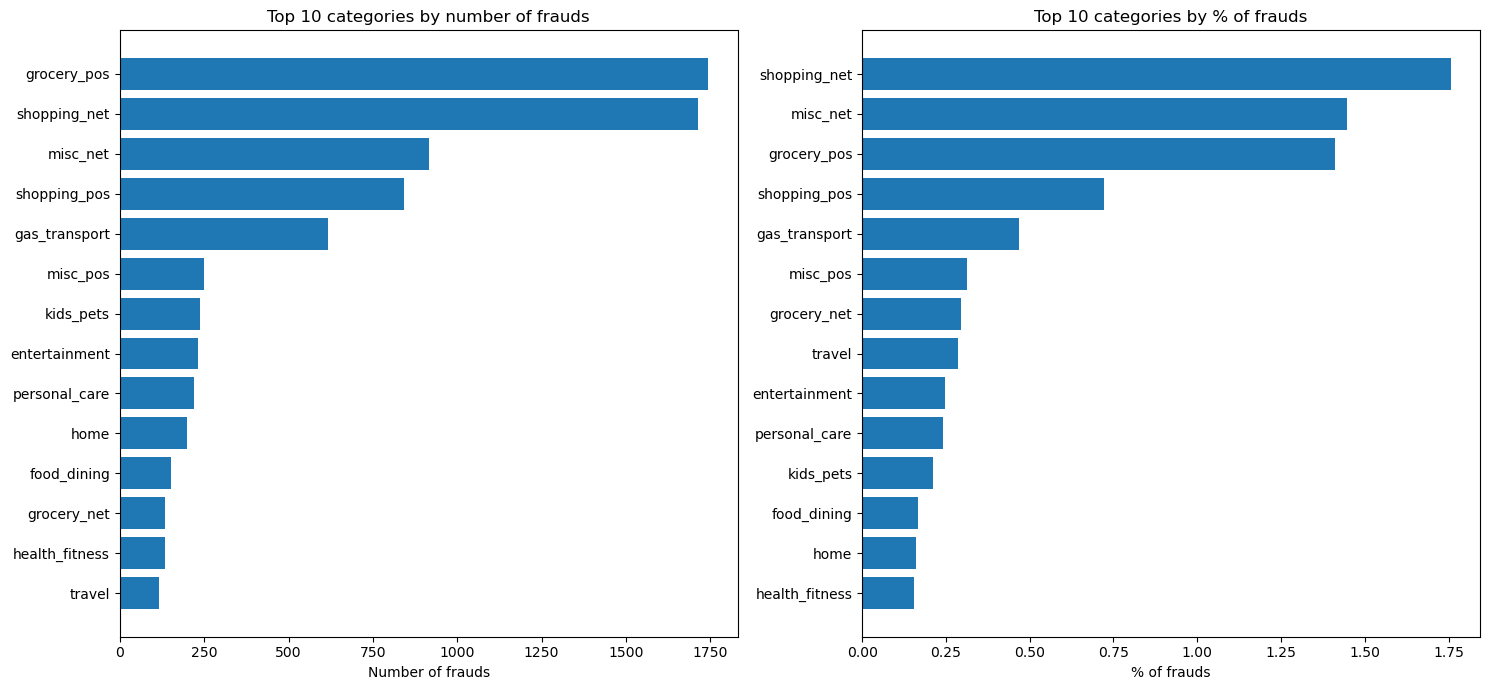

In [9]:
trans_cat = df["category"].value_counts()
fraud_cat = df[df["is_fraud"] == 1]["category"].value_counts()
perc_frauds_cat = (fraud_cat / trans_cat * 100).dropna().sort_values(ascending=True)
fraud_cat_sorted = fraud_cat.sort_values(ascending=True)

fig, ax = plt.subplots(ncols=2, figsize=(15, 7))

ax[0].barh(fraud_cat_sorted.index, fraud_cat_sorted.values)
ax[0].set_xlabel("Number of frauds")
ax[0].set_title("Top 10 categories by number of frauds")

ax[1].barh(perc_frauds_cat.index, perc_frauds_cat.values)
ax[1].set_xlabel("% of frauds")
ax[1].set_title("Top 10 categories by % of frauds")

plt.tight_layout()
plt.show()

A clear signal emerges: while the most represented categories in absolute terms are everyday ones such as groceries and shopping, the fraud rate is dominated by online transactions — those belonging to categories ending with the *_net* suffix.

Before moving to the next feature, we briefly inspect `merchant` to verify whether it carries any signal beyond what `category` already captures.

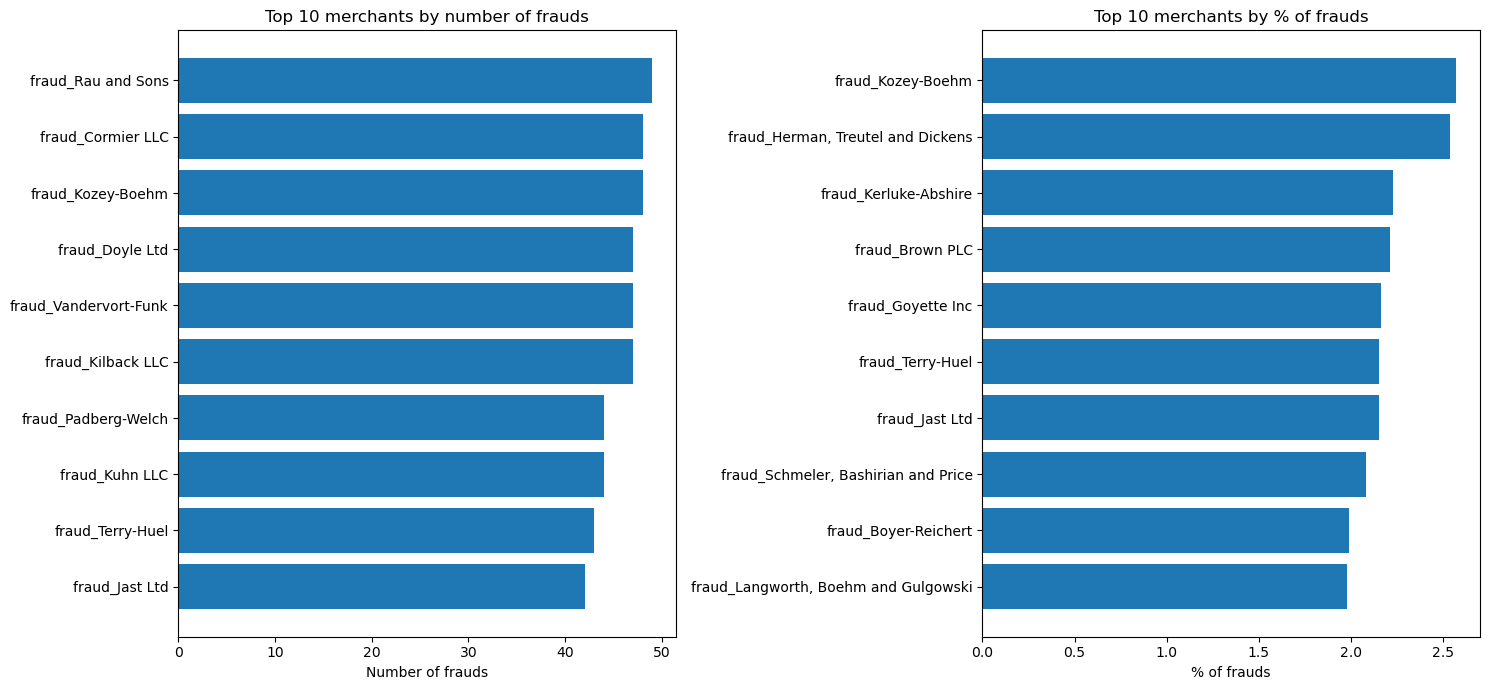

In [10]:
trans_merch = df['merchant'].value_counts()
fraud_merch = df[df['is_fraud'] == 1]['merchant'].value_counts()

top20_abs = fraud_merch.sort_values(ascending=True).tail(10)
top20_perc = (fraud_merch / trans_merch * 100).dropna().sort_values(ascending=True).tail(10)

fig, ax = plt.subplots(ncols=2, figsize=(15, 7))

ax[0].barh(top20_abs.index, top20_abs.values)
ax[0].set_xlabel("Number of frauds")
ax[0].set_title("Top 10 merchants by number of frauds")

ax[1].barh(top20_perc.index, top20_perc.values)
ax[1].set_xlabel("% of frauds")
ax[1].set_title("Top 10 merchants by % of frauds")

plt.tight_layout()
plt.show()

The `merchant` feature has approximately 700 unique values. We limit the analysis to the top 10 merchants by absolute fraud count and by fraud rate, following the same dual-perspective approach used throughout the EDA.

No consistent signal emerges from the merchant-level analysis. The merchants with the highest fraud rates are those with very few total transactions — a statistical artefact rather than a genuine pattern. With ~700 unique values and no signal beyond what `category` already captures at cardinality 14, `merchant` will be dropped.

We now turn to the `amt` feature, which represents the transaction amount in dollars.

Stats legit transactions
count    1.289169e+06
mean     6.766711e+01
std      1.540080e+02
min      1.000000e+00
25%      9.610000e+00
50%      4.728000e+01
75%      8.254000e+01
max      2.894890e+04
Name: amt, dtype: float64

Stats frauds
count    7506.000000
mean      531.320092
std       390.560070
min         1.060000
25%       245.662500
50%       396.505000
75%       900.875000
max      1376.040000
Name: amt, dtype: float64


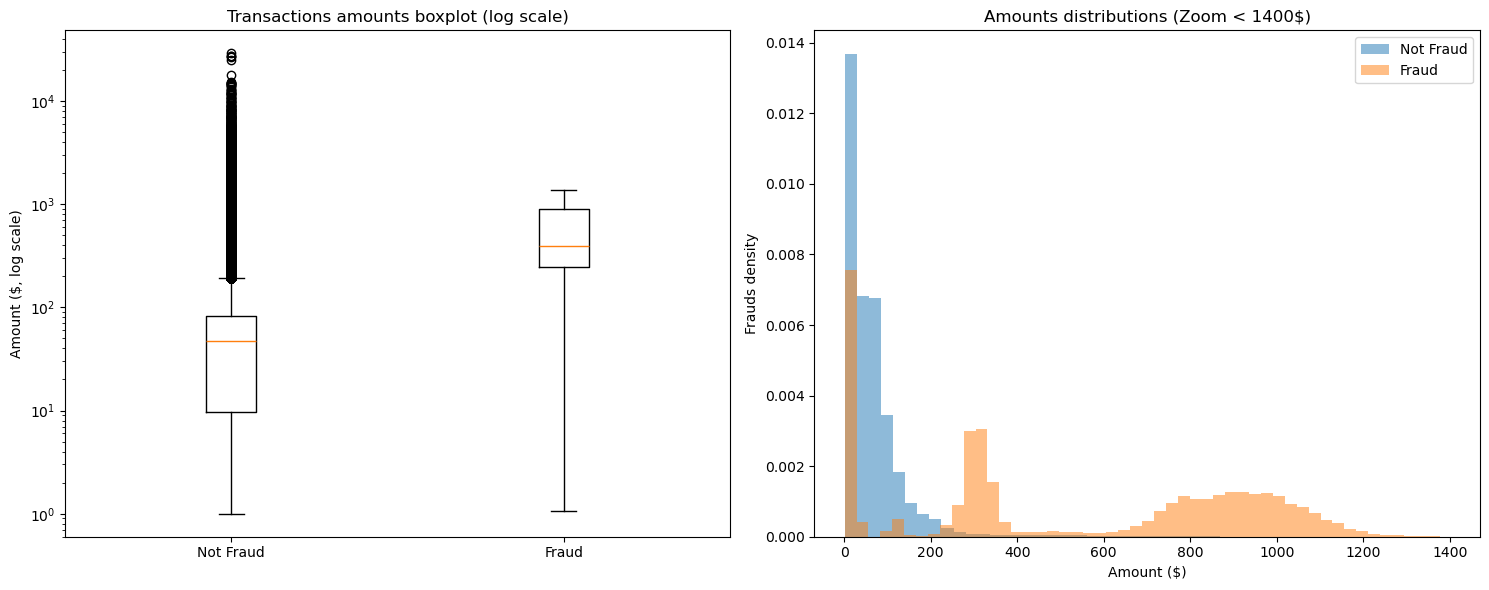

In [11]:
print("Stats legit transactions")
print(df[df['is_fraud'] == 0]['amt'].describe())
print("\nStats frauds")
print(df[df['is_fraud'] == 1]['amt'].describe())

fig, ax = plt.subplots(ncols=2, figsize=(15, 6))

ax[0].boxplot([df[df["is_fraud"]==0]["amt"], df[df["is_fraud"]==1]["amt"]], tick_labels=["Not Fraud", "Fraud"])
ax[0].set_yscale("log") 
ax[0].set_ylabel("Amount ($, log scale)")
ax[0].set_title("Transactions amounts boxplot (log scale)")

ax[1].hist(df[(df["is_fraud"]==0) & (df["amt"] < 1400)]["amt"], bins=50, alpha=0.5, label="Not Fraud", density=True)
ax[1].hist(df[(df["is_fraud"]==1) & (df["amt"] < 1400)]["amt"], bins=50, alpha=0.5, label="Fraud", density=True)
ax[1].set_xlabel("Amount ($)")
ax[1].set_ylabel("Frauds density")
ax[1].set_title("Amounts distributions")
ax[1].legend()

plt.tight_layout()
plt.show()

The printed statistics, boxplots, and empirical distributions converge on a clear picture: legitimate transactions are concentrated in the range of tens of dollars, with a long but thin tail of occasional large purchases. Fraudulent transactions show a distinctly different profile — fraudsters typically begin with small test charges to verify the card is active, then follow up with larger transactions in the hundreds of dollars.

We next examine `dob` to check whether the cardholder's age is associated with fraud likelihood.

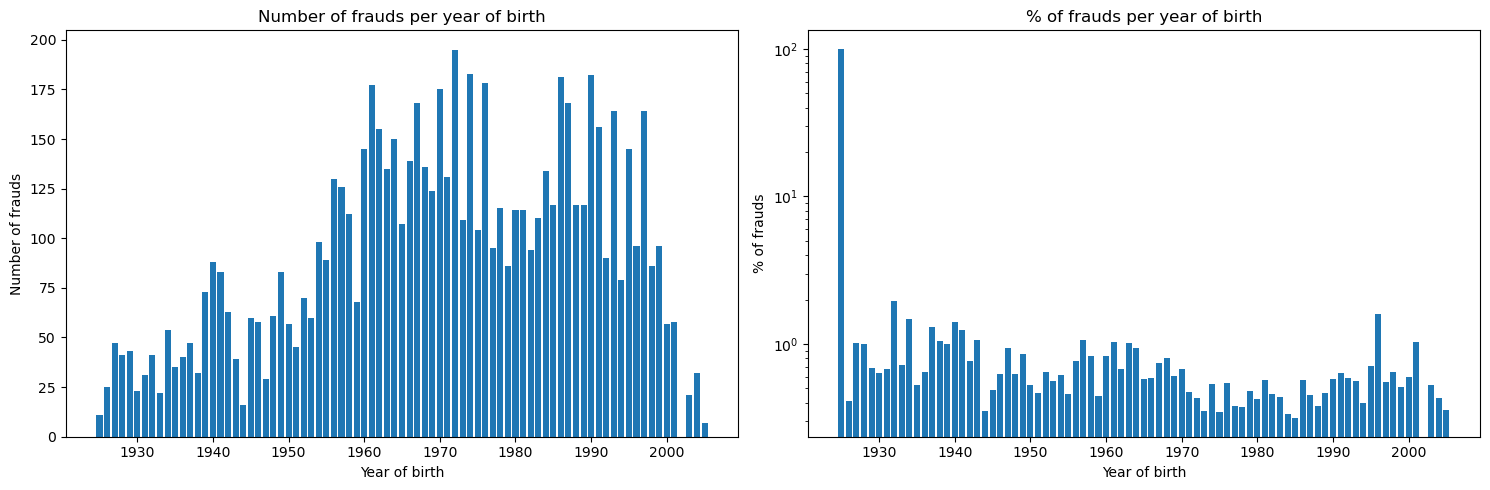

In [12]:
trans_yob = df["dob"].dt.year
fraud_yob = df[df["is_fraud"] == 1]["dob"].dt.year
trans_yob_counts = trans_yob.value_counts().sort_index()
fraud_yob_counts = fraud_yob.value_counts().sort_index()
perc_frauds_yob = (fraud_yob_counts / trans_yob_counts) * 100

fig, ax = plt.subplots(ncols=2, figsize=(15, 5))

ax[0].bar(fraud_yob_counts.index, fraud_yob_counts.values)
ax[0].set_xlabel("Year of birth")
ax[0].set_ylabel("Number of frauds")
ax[0].set_title("Number of frauds per year of birth")


ax[1].bar(perc_frauds_yob.index, perc_frauds_yob.values)
ax[1].set_xlabel("Year of birth")
ax[1].set_ylabel("% of frauds")
ax[1].set_yscale("log")
ax[1].set_title("% of frauds per year of birth")


plt.tight_layout()
plt.show()

In [13]:
df[df["dob"].dt.year==1925][["cc_num","is_fraud"]].value_counts()

cc_num            is_fraud
4492677353108006  1           11
Name: count, dtype: int64

The absolute fraud count by birth year simply reflects the active population (roughly those born between 1960 and 2000), with no age-related pattern in the fraud rate. The spike at 1925 appears anomalous but is entirely explained by a single compromised card — confirmed by the lookup above. Age carries no predictive signal and `dob` will be dropped.

We now check whether the distance between the cardholder's home location (`lat`, `long`) and the merchant's location (`merch_lat`, `merch_long`) is informative.

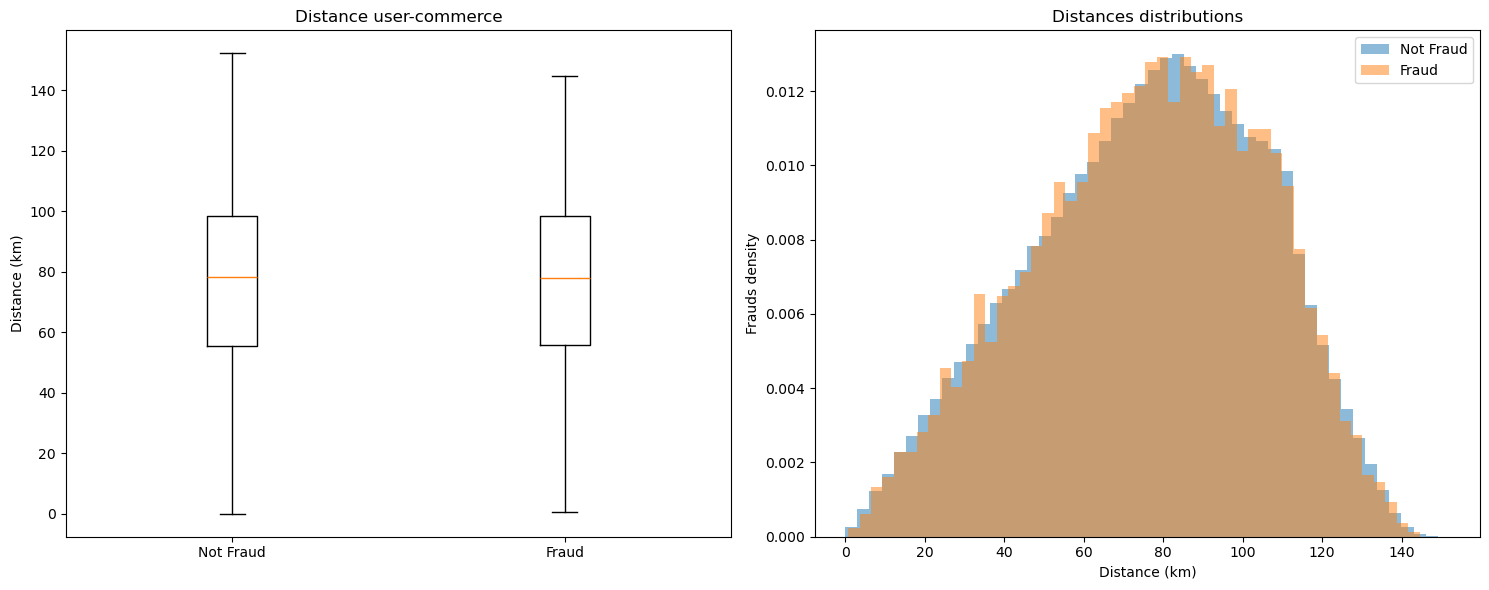

In [14]:
def haversine_distance(lat1, lon1, lat2, lon2):
    R = 6371.0 
    lat1, lon1, lat2, lon2 = map(np.radians, [lat1, lon1, lat2, lon2])
    dlat = lat2 - lat1
    dlon = lon2 - lon1
    a = np.sin(dlat/2)**2 + np.cos(lat1) * np.cos(lat2) * np.sin(dlon/2)**2
    c = 2 * np.arcsin(np.sqrt(a))
    d=R*c
    return d

dist_km = haversine_distance(df['lat'], df['long'], df['merch_lat'], df['merch_long'])

fig, ax = plt.subplots(ncols=2, figsize=(15, 6))

ax[0].boxplot([dist_km[df["is_fraud"]==0], dist_km[df["is_fraud"]==1]], tick_labels=["Not Fraud", "Fraud"])
ax[0].set_ylabel("Distance (km)")
ax[0].set_title("Distance user-commerce")

ax[1].hist(dist_km[df["is_fraud"]==0], bins=50, alpha=0.5, label="Not Fraud", density=True)
ax[1].hist(dist_km[df["is_fraud"]==1], bins=50, alpha=0.5, label="Fraud", density=True)
ax[1].set_xlabel("Distance (km)")
ax[1].set_ylabel("Frauds density")
ax[1].set_title("Distances distributions")
ax[1].legend()

plt.tight_layout()
plt.show()

We compute the great-circle distance between the cardholder's registered address and the merchant location using the Haversine formula. Both the boxplots and the empirical distributions are nearly identical for fraudulent and legitimate transactions, confirming that geographical distance carries no useful signal.

We now check whether the cardholder's `gender` is a relevant predictor.

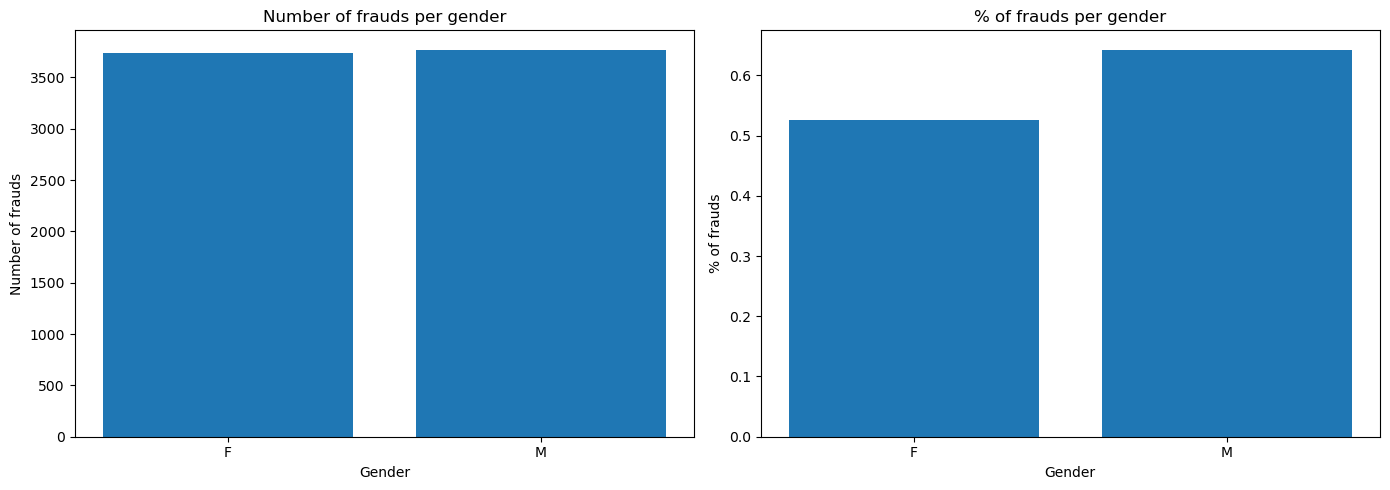

In [15]:
trans_gender = df['gender'].value_counts().sort_index()
fraud_gender = df[df['is_fraud']==1]['gender'].value_counts().sort_index()
perc_gender = (fraud_gender / trans_gender) * 100

fig, ax = plt.subplots(ncols=2, figsize=(14, 5))

ax[0].bar(fraud_gender.index, fraud_gender.values)
ax[0].set_xlabel("Gender")
ax[0].set_ylabel("Number of frauds")
ax[0].set_title("Number of frauds per gender")

ax[1].bar(perc_gender.index, perc_gender.values)
ax[1].set_xlabel("Gender")
ax[1].set_ylabel("% of frauds")
ax[1].set_title("% of frauds per gender")

plt.tight_layout()
plt.show()

Gender carries no predictive signal: the fraud rate is essentially identical across both groups.

We next examine `city_pop`, the population of the cardholder's city of residence.

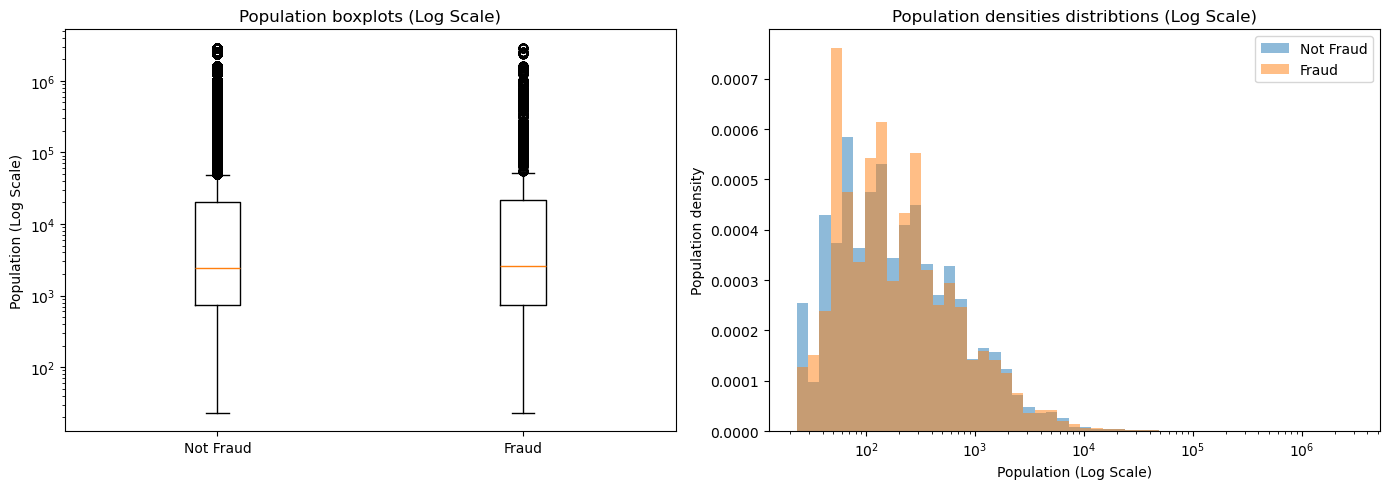

In [16]:
fig, ax = plt.subplots(ncols=2, figsize=(14, 5))

ax[0].boxplot([df[df["is_fraud"]==0]["city_pop"], df[df["is_fraud"]==1]["city_pop"]], tick_labels=["Not Fraud", "Fraud"])
ax[0].set_yscale("log")
ax[0].set_ylabel("Population (Log Scale)")
ax[0].set_title("Population boxplots (Log Scale)")

bins = np.logspace(np.log10(df['city_pop'].min()), np.log10(df['city_pop'].max()), 50)
ax[1].hist(df[df["is_fraud"]==0]["city_pop"], bins=bins, alpha=0.5, label="Not Fraud", density=True)
ax[1].hist(df[df["is_fraud"]==1]["city_pop"], bins=bins, alpha=0.5, label="Fraud", density=True)
ax[1].set_xscale("log")
ax[1].set_xlabel("Population (Log Scale)")
ax[1].set_ylabel("Population density")
ax[1].set_title("Population densities distribtions (Log Scale)")
ax[1].legend()

plt.tight_layout()
plt.show()

The distributions of city population are nearly identical for fraudulent and legitimate transactions — no useful signal here either.

To complete the geographical analysis, we examine fraud rates by US state. We deliberately avoid analysing raw coordinates at finer granularity, as the high dimensionality would introduce noise rather than signal.

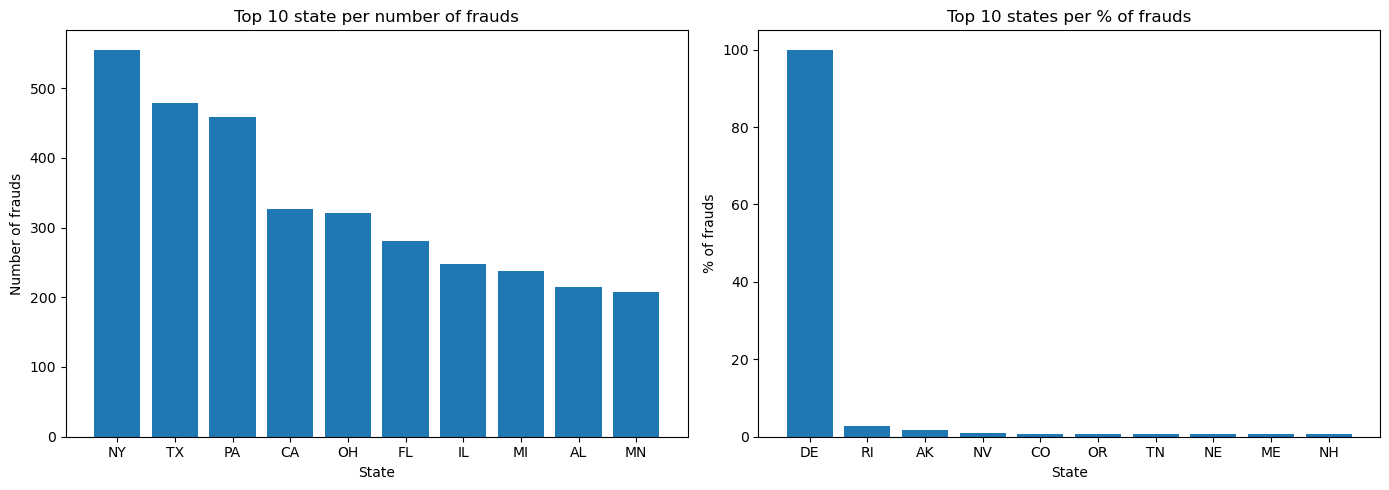

In [17]:
trans_state = df['state'].value_counts()
fraud_state = df[df['is_fraud']==1]['state'].value_counts()

top10_abs = fraud_state.sort_values(ascending=False).head(10)
perc_state = (fraud_state / trans_state * 100).sort_values(ascending=False).head(10)

fig, ax = plt.subplots(ncols=2, figsize=(14, 5))

ax[0].bar(top10_abs.index, top10_abs.values)
ax[0].set_xlabel("State")
ax[0].set_ylabel("Number of frauds")
ax[0].set_title("Top 10 state per number of frauds")

ax[1].bar(perc_state.index, perc_state.values)
ax[1].set_xlabel("State")
ax[1].set_ylabel("% of frauds")
ax[1].set_title("Top 10 states per % of frauds")

plt.tight_layout()
plt.show()

In [18]:
df[df['state']=='DE'][["cc_num","state","is_fraud"]].value_counts()

cc_num            state  is_fraud
6011826317034777  DE     1           9
Name: count, dtype: int64

In absolute terms, no state shows a disproportionately high fraud count. Delaware (DE) appears to stand out in relative terms, but a closer look reveals that a single compromised card accounts for all fraudulent transactions in that state — the same statistical artefact encountered with the 1925 birth year. No geographical feature at any granularity carries actionable signal.

We conclude the EDA by analysing transaction velocity: the time elapsed between consecutive transactions on the same card.

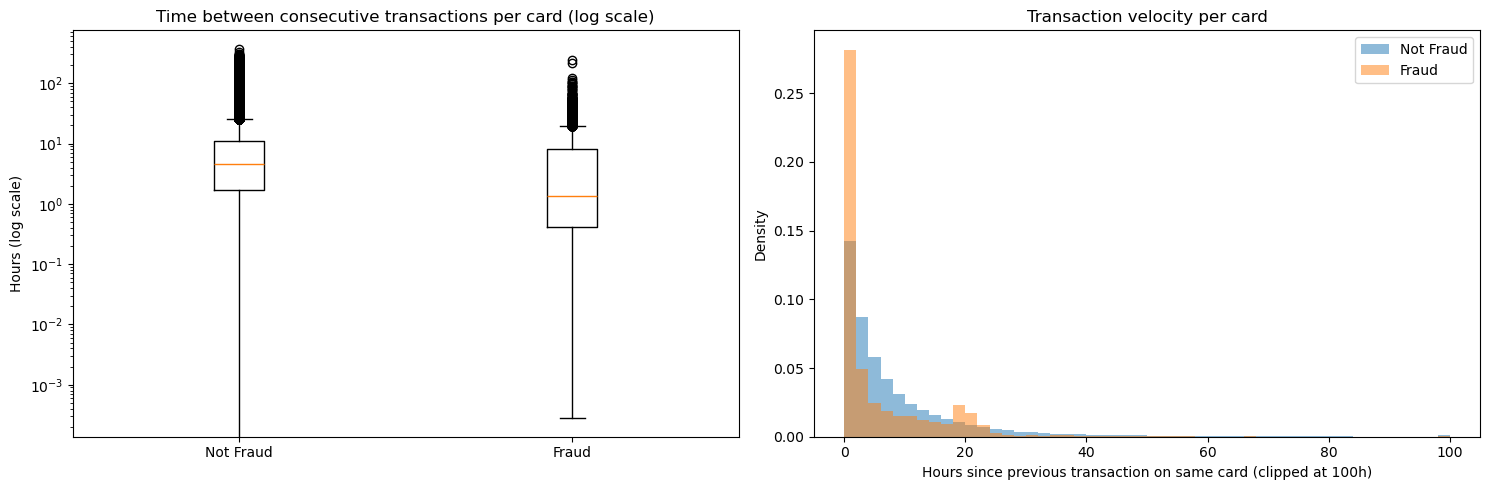

Median hours since last transaction — Not Fraud: 4.6h
Median hours since last transaction — Fraud:     1.4h


In [19]:
df_vel = df[['cc_num', 'unix_time', 'is_fraud']].sort_values(['cc_num', 'unix_time'])
df_vel['hours_since_last'] = df_vel.groupby('cc_num')['unix_time'].diff() / 3600

legit_intervals = df_vel[df_vel['is_fraud'] == 0]['hours_since_last'].dropna()
fraud_intervals = df_vel[df_vel['is_fraud'] == 1]['hours_since_last'].dropna()

clip_h = 100
fig, ax = plt.subplots(ncols=2, figsize=(15, 5))

ax[0].boxplot([legit_intervals, fraud_intervals], tick_labels=['Not Fraud', 'Fraud'])
ax[0].set_yscale('log')
ax[0].set_ylabel('Hours (log scale)')
ax[0].set_title('Time between consecutive transactions per card (log scale)')

ax[1].hist(legit_intervals.clip(upper=clip_h), bins=50, alpha=0.5, label='Not Fraud', density=True)
ax[1].hist(fraud_intervals.clip(upper=clip_h), bins=50, alpha=0.5, label='Fraud', density=True)
ax[1].set_xlabel(f'Hours since previous transaction on same card (clipped at {clip_h}h)')
ax[1].set_ylabel('Density')
ax[1].set_title('Transaction velocity per card')
ax[1].legend()

plt.tight_layout()
plt.show()

print(f"Median hours since last transaction — Not Fraud: {legit_intervals.median():.1f}h")
print(f"Median hours since last transaction — Fraud:     {fraud_intervals.median():.1f}h")

Fraudulent transactions occur significantly closer together in time than legitimate ones: the median interval drops from 4.6 hours for legitimate transactions to 1.4 hours for fraudulent ones. This is consistent with the typical fraud pattern — a burst of rapid charges once a card is stolen. The time elapsed since the last transaction on the same card (`hours_since_last_trans`) is a strong candidate for feature engineering.

The raw `amt` feature carries meaningful signal, but its discriminative power increases when conditioned on the purchase category. A transaction of $500 is unremarkable for `shopping_net` but anomalous for `gas_transport`. We engineer `amt_zscore_per_category` as the z-score of `amt` within each category, computed using the mean and standard deviation of legitimate transactions only — making it a measure of how unusual a given amount is relative to the typical spend in that category.

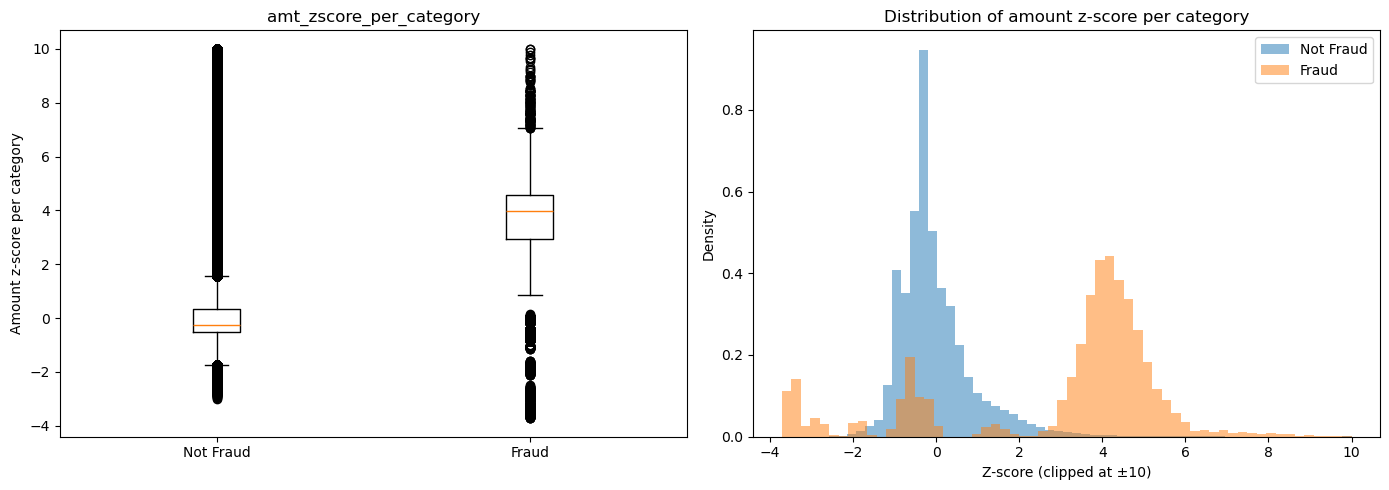

Median   — Not Fraud: -0.26   Fraud: 3.98


In [20]:
cat_mean = df[df['is_fraud'] == 0].groupby('category')['amt'].mean()
cat_std  = df[df['is_fraud'] == 0].groupby('category')['amt'].std()

amt_z   = (df['amt'] - df['category'].map(cat_mean)) / (df['category'].map(cat_std) + 1e-6)
legit_z = amt_z[df['is_fraud'] == 0]
fraud_z = amt_z[df['is_fraud'] == 1]

clip_z = 10
fig, ax = plt.subplots(ncols=2, figsize=(14, 5))

ax[0].boxplot([legit_z.clip(-clip_z, clip_z), fraud_z.clip(-clip_z, clip_z)],
              tick_labels=['Not Fraud', 'Fraud'])
ax[0].set_ylabel('Amount z-score per category')
ax[0].set_title('amt_zscore_per_category')

ax[1].hist(legit_z.clip(-clip_z, clip_z), bins=60, alpha=0.5, label='Not Fraud', density=True)
ax[1].hist(fraud_z.clip(-clip_z, clip_z), bins=60, alpha=0.5, label='Fraud', density=True)
ax[1].set_xlabel('Z-score (clipped at ±10)')
ax[1].set_ylabel('Density')
ax[1].set_title('Distribution of amount z-score per category')
ax[1].legend()

plt.tight_layout()
plt.show()

print(f"Median   — Not Fraud: {legit_z.median():.2f}   Fraud: {fraud_z.median():.2f}")


`amt_zscore_per_category` normalises the amount relative to the category — but two cardholders in the same category can have very different spending habits. A $300 charge on `misc_net` may be typical for one cardholder and three standard deviations above their norm for another. We engineer `amt_zscore_per_card` to visualise how anomalous a given amount is *for this specific card*.

Note: for visualisation purposes only, this EDA uses a full-history per-card mean and std (non-causal). In both supervised (Fase 1) and unsupervised (Fase 2) models, this feature is computed with an expanding window and a one-step shift to prevent look-ahead leakage — purely temporal, no fraud labels required.

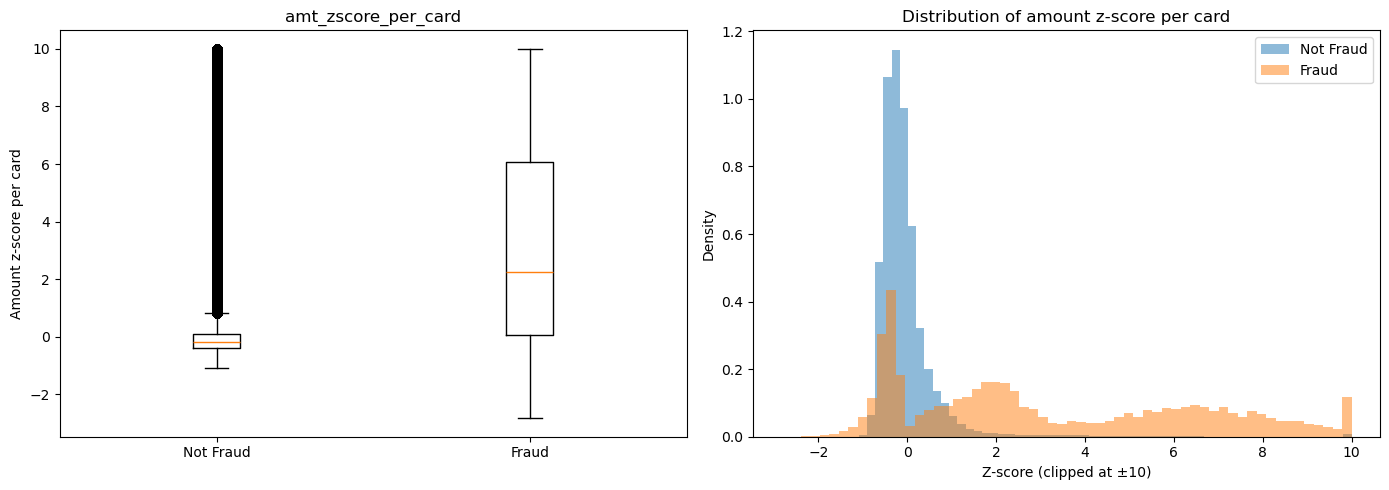

Median   — Not Fraud: -0.18   Fraud: 2.26


In [21]:
card_mean  = df.groupby('cc_num')['amt'].transform('mean')
card_std   = df.groupby('cc_num')['amt'].transform('std')
amt_z_card = (df['amt'] - card_mean) / (card_std + 1e-6)

legit_zc = amt_z_card[df['is_fraud'] == 0]
fraud_zc = amt_z_card[df['is_fraud'] == 1]

clip_z = 10
fig, ax = plt.subplots(ncols=2, figsize=(14, 5))

ax[0].boxplot([legit_zc.clip(-clip_z, clip_z), fraud_zc.clip(-clip_z, clip_z)],
              tick_labels=['Not Fraud', 'Fraud'])
ax[0].set_ylabel('Amount z-score per card')
ax[0].set_title('amt_zscore_per_card')

ax[1].hist(legit_zc.clip(-clip_z, clip_z), bins=60, alpha=0.5, label='Not Fraud', density=True)
ax[1].hist(fraud_zc.clip(-clip_z, clip_z), bins=60, alpha=0.5, label='Fraud', density=True)
ax[1].set_xlabel('Z-score (clipped at ±10)')
ax[1].set_ylabel('Density')
ax[1].set_title('Distribution of amount z-score per card')
ax[1].legend()

plt.tight_layout()
plt.show()

print(f"Median   — Not Fraud: {legit_zc.median():.2f}   Fraud: {fraud_zc.median():.2f}")

### Additional Feature Engineering

The EDA above pinpointed four signals not yet captured in the feature set: transaction burst density, the online-vs-offline channel, card history depth, and physical travel plausibility. We engineer and visualise each feature below — all purely temporal, no fraud labels required — before incorporating them in the models.

#### Nighttime flag — `is_night`

The hourly EDA identified a sharp, discontinuous fraud spike concentrated between **22:00 and 3:00**. The cyclical sin/cos encoding represents hour as a smooth wave, but the crime window is a hard 5-hour range. A binary flag directly exposes the strongest temporal signal in the dataset without requiring any model to learn the discontinuity from curvature.

In [ ]:
_hour_eda = df['trans_date_trans_time'].dt.hour
df_night  = df.copy()
df_night['is_night'] = _hour_eda.isin([22, 23, 0, 1, 2]).astype(int)

trans_night = df_night['is_night'].value_counts()
fraud_night  = df_night[df_night['is_fraud'] == 1]['is_night'].value_counts()
perc_night   = (fraud_night / trans_night * 100).reindex([0, 1]).fillna(0)

fig, ax = plt.subplots(ncols=2, figsize=(12, 4))
ax[0].bar(['Day', 'Night (22–3)'], [fraud_night.get(0, 0), fraud_night.get(1, 0)])
ax[0].set_ylabel('Number of frauds')
ax[0].set_title('Fraud count by time of day')
ax[1].bar(['Day', 'Night (22–3)'], perc_night.values)
ax[1].set_ylabel('% of transactions that are fraud')
ax[1].set_title('Fraud rate: day vs night')
plt.tight_layout()
plt.show()
print(f"Fraud rate — Day: {perc_night[0]:.2f}%   Night (22:00–3:00): {perc_night[1]:.2f}%")

The nighttime fraud rate is **13×** the daytime rate (2.2% vs 0.17%). `is_night` distils the strongest temporal signal of the entire EDA into a single binary feature. Together with `is_online`, it provides direct access to the two sharpest fraud-rate discontinuities in the dataset.

#### Card history depth — `n_prev_tx_card`

`amt_zscore_card` uses an expanding mean and std that are statistically unreliable when few prior transactions exist. `n_prev_tx_card` — the count of prior transactions on the same card — makes this cold-start uncertainty explicit, giving the model a signal about how much historical context is available.

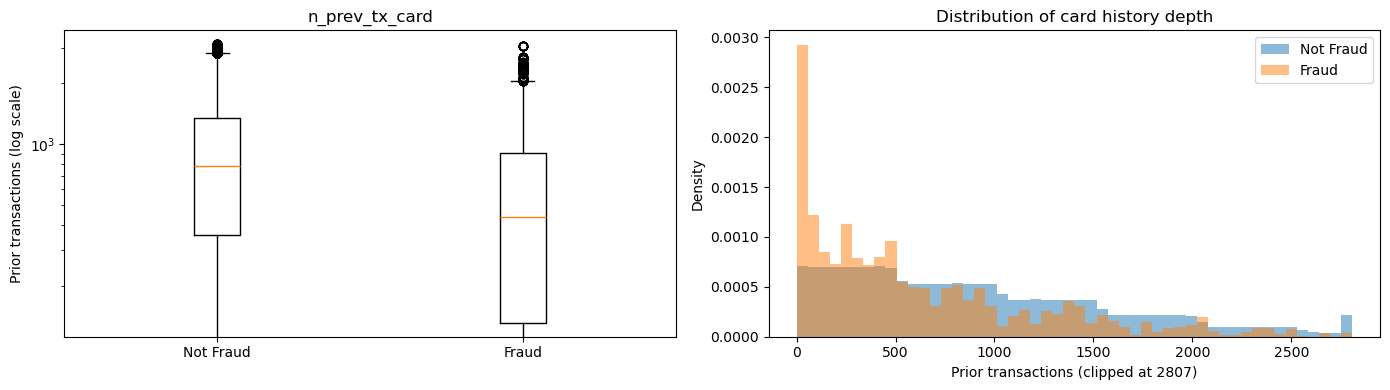

Median n_prev_tx_card — Not Fraud: 779   Fraud: 438


In [24]:
_df_np  = df.sort_values(['cc_num', 'unix_time'])
_n_prev = _df_np.groupby('cc_num').cumcount()
_n_prev.index = _df_np.index

lv_np   = _n_prev[df['is_fraud'] == 0]
fv_np   = _n_prev[df['is_fraud'] == 1]
clip_np = int(lv_np.quantile(0.99))

fig, ax = plt.subplots(ncols=2, figsize=(14, 4))
ax[0].boxplot([lv_np, fv_np], tick_labels=['Not Fraud', 'Fraud'])
ax[0].set_yscale('log')
ax[0].set_ylabel('Prior transactions (log scale)')
ax[0].set_title('n_prev_tx_card')
ax[1].hist(lv_np.clip(upper=clip_np), bins=50, alpha=0.5, label='Not Fraud', density=True)
ax[1].hist(fv_np.clip(upper=clip_np), bins=50, alpha=0.5, label='Fraud', density=True)
ax[1].set_xlabel(f'Prior transactions (clipped at {clip_np})')
ax[1].set_ylabel('Density')
ax[1].set_title('Distribution of card history depth')
ax[1].legend()
plt.tight_layout(); plt.show()
print(f"Median n_prev_tx_card — Not Fraud: {lv_np.median():.0f}   Fraud: {fv_np.median():.0f}")

The distributions are broadly similar, confirming that `n_prev_tx_card` acts primarily as a contextual calibration signal (how much should the model trust its card-level aggregates) rather than as a standalone fraud discriminator.

#### Geographic velocity — `geo_velocity`

A card used in Turin at 22:00 and in New York at 22:10 implies a travel speed of ~8,500 km/h — physically impossible. `geo_velocity` computes the great-circle distance between consecutive merchant locations divided by elapsed time (km/h). Physical implausibility is a near-certain fraud indicator that raw coordinates cannot capture on their own.

**Implementation:** Haversine distance on `merch_lat/long` consecutive pairs; first transaction per card set to 0; velocities capped at 10,000 km/h to prevent extreme outliers from dominating the scale.

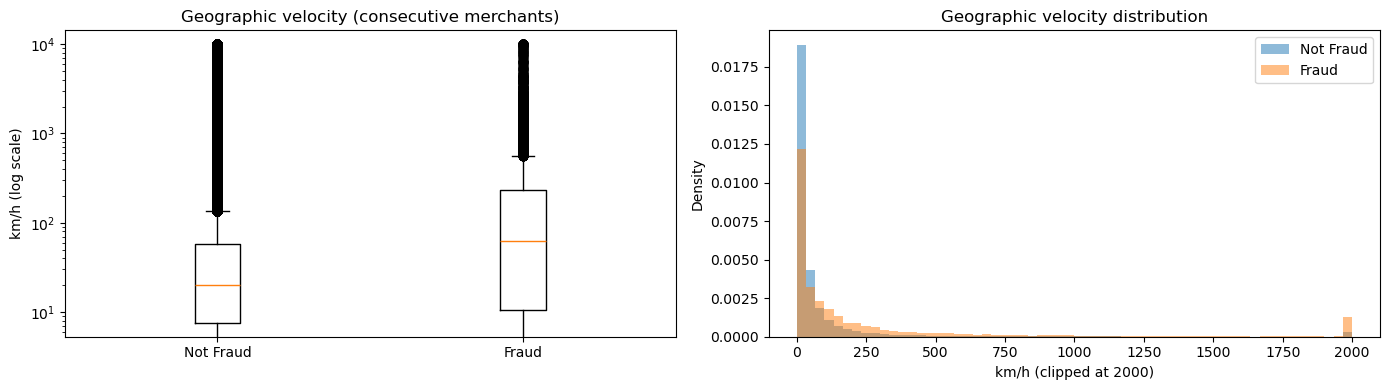

Median geo_velocity        — Not Fraud: 19.9 km/h   Fraud: 62.1 km/h
% with geo_velocity > 1000 — Not Fraud: 1.90%   Fraud: 7.59%


In [25]:
_dg = df[['cc_num', 'unix_time', 'merch_lat', 'merch_long', 'is_fraud']].sort_values(['cc_num', 'unix_time']).copy()
_dg['prev_mlat']  = _dg.groupby('cc_num')['merch_lat'].shift(1)
_dg['prev_mlong'] = _dg.groupby('cc_num')['merch_long'].shift(1)
_dg['dt_h']       = _dg.groupby('cc_num')['unix_time'].diff() / 3600

_dist_gv = haversine_distance(
    _dg['merch_lat'], _dg['merch_long'],
    _dg['prev_mlat'].fillna(_dg['merch_lat']),
    _dg['prev_mlong'].fillna(_dg['merch_long'])
)
_valid = _dg['dt_h'].notna() & (_dg['dt_h'] > 0)
_dg['geo_velocity'] = 0.0
_dg.loc[_valid, 'geo_velocity'] = (_dist_gv[_valid] / _dg.loc[_valid, 'dt_h']).clip(upper=10000)

lv_gv = _dg[_dg['is_fraud'] == 0]['geo_velocity']
fv_gv = _dg[_dg['is_fraud'] == 1]['geo_velocity']

fig, ax = plt.subplots(ncols=2, figsize=(14, 4))
ax[0].boxplot([lv_gv, fv_gv], tick_labels=['Not Fraud', 'Fraud'])
ax[0].set_yscale('log')
ax[0].set_ylabel('km/h (log scale)')
ax[0].set_title('Geographic velocity (consecutive merchants)')
ax[1].hist(lv_gv.clip(upper=2000), bins=60, alpha=0.5, label='Not Fraud', density=True)
ax[1].hist(fv_gv.clip(upper=2000), bins=60, alpha=0.5, label='Fraud', density=True)
ax[1].set_xlabel('km/h (clipped at 2000)')
ax[1].set_ylabel('Density')
ax[1].set_title('Geographic velocity distribution')
ax[1].legend()
plt.tight_layout(); plt.show()
print(f"Median geo_velocity        — Not Fraud: {lv_gv.median():.1f} km/h   Fraud: {fv_gv.median():.1f} km/h")
print(f"% with geo_velocity > 1000 — Not Fraud: {(lv_gv > 1000).mean()*100:.2f}%   Fraud: {(fv_gv > 1000).mean()*100:.2f}%")

The high-velocity tail is more pronounced for fraud. The feature is sparse — most transactions occur near the cardholder's home — but physically impossible velocities (> ~1,000 km/h) are a near-certain indicator of card cloning or simultaneous use. Its discriminative power concentrates in the high-percentile tail rather than in median statistics.

## Metrics evaluation function

In [26]:
def evaluate_model(y_val, y_proba, model_name="Model", threshold=0.5):
    y_pred  = (y_proba >= threshold).astype(int)

    print(f"\n{'═'*44}")
    print(f"  {model_name}")
    print(f"{'─'*44}")
    print(f"  PR-AUC  (primary)   {average_precision_score(y_val, y_proba):.4f}")
    print(f"  ROC-AUC             {roc_auc_score(y_val, y_proba):.4f}")
    print(f"{'─'*44}")
    print(classification_report(y_val, y_pred, target_names=['Not Fraud', 'Fraud']))
    print(f"{'═'*44}\n")

    fig, ax = plt.subplots(ncols=3, figsize=(18, 5))
    ConfusionMatrixDisplay.from_predictions(y_val, y_pred, ax=ax[0],
                                            display_labels=['Not Fraud', 'Fraud'])
    ax[0].set_title('Confusion Matrix')
    RocCurveDisplay.from_predictions(y_val, y_proba, ax=ax[1])
    ax[1].set_title('ROC Curve')
    PrecisionRecallDisplay.from_predictions(y_val, y_proba, ax=ax[2])
    ax[2].set_title('Precision-Recall Curve')
    fig.suptitle(model_name, fontsize=13, fontweight='bold')
    plt.tight_layout()
    plt.show()

## Fase 1 — Supervised Models

We establish the supervised ceiling with full label access. **Logistic Regression** serves as the linear baseline; **LightGBM** as the non-linear champion. Both models use the same hand-crafted feature set: transaction velocity, cyclical hour encoding, and card- and category-level amount z-scores.

This section answers a single question: *how well can a supervised model perform when fraud labels are abundant?* The answer sets the benchmark that Fase 3 will probe as labels are progressively removed.

## Supervised Baseline — Logistic Regression

Logistic Regression establishes the supervised baseline. With `class_weight='balanced'` the model reweights the minority class to compensate for the ~170:1 imbalance. Log-transforming `amt` and `hours_since_last_trans` linearises their right-skewed distributions, making them accessible to a linear decision boundary. Any non-linear method should comfortably surpass this baseline.

### Feature Engineering

In [27]:
df_baseline = df.copy()
df_baseline = df_baseline.sort_values(['cc_num', 'unix_time'])

df_baseline['hours_since_last_trans'] = df_baseline.groupby('cc_num')['unix_time'].diff() / 3600
df_baseline['hours_since_last_trans'] = df_baseline['hours_since_last_trans'].fillna(
    df_baseline['hours_since_last_trans'].median()
)

_hour = df_baseline['trans_date_trans_time'].dt.hour
df_baseline['hour_sin'] = np.sin(2 * np.pi * _hour / 24)
df_baseline['hour_cos'] = np.cos(2 * np.pi * _hour / 24)

_cat_mean = df[df['is_fraud'] == 0].groupby('category', observed=True)['amt'].mean()
_cat_std  = df[df['is_fraud'] == 0].groupby('category', observed=True)['amt'].std()

df_baseline['amt_zscore_cat'] = (
    (df_baseline['amt'] - df_baseline['category'].map(_cat_mean))
    / (df_baseline['category'].map(_cat_std) + 1e-6)
)

_g = df_baseline.groupby('cc_num')['amt']
df_baseline['amt_zscore_card'] = (
    (df_baseline['amt'] - _g.transform(lambda x: x.expanding().mean().shift(1)))
    / (_g.transform(lambda x: x.expanding().std().shift(1)) + 1e-6)
).fillna(0)

df_baseline['amt'] = np.log1p(df_baseline['amt'])
df_baseline['hours_since_last_trans'] = np.log1p(df_baseline['hours_since_last_trans'])

cols_to_drop = ['trans_num', 'cc_num', 'first', 'last', 'gender',
                'street', 'city', 'state', 'zip', 'lat', 'long',
                'merch_lat', 'merch_long', 'city_pop', 'job',
                'merchant', 'unix_time', 'dob', 'trans_date_trans_time']
df_baseline = df_baseline.drop(columns=cols_to_drop).sort_index()


### Preprocessing

In [28]:
X = df_baseline.drop(columns=['is_fraud'])
y = df_baseline['is_fraud']

X_train, X_val, y_train, y_val = train_test_split(X, y, test_size=0.2, shuffle=False)

num_features = ['amt', 'hours_since_last_trans', 'hour_sin', 'hour_cos', 'amt_zscore_cat', 'amt_zscore_card']
cat_features = ['category']

preprocessor = ColumnTransformer([
    ('ohe', OneHotEncoder(handle_unknown='ignore'), cat_features),
    ('scaler', StandardScaler(), num_features)
])

pipe = Pipeline([
    ('pre', preprocessor),
    ('clf', LogisticRegression(class_weight='balanced', max_iter=1000, random_state=42, n_jobs=-1))
])

pipe.fit(X_train, y_train)


,steps,"[('pre', ...), ('clf', ...)]"
,transform_input,None
,memory,None
,verbose,False
,transformers,"[('ohe', ...), ('scaler', ...)]"
,remainder,'drop'
,sparse_threshold,0.3
,n_jobs,None
,transformer_weights,None
,verbose,False
,verbose_feature_names_out,True


### LogReg - Model evalutaion


════════════════════════════════════════════
  Logistic Regression
────────────────────────────────────────────
  PR-AUC  (primary)   0.2489
  ROC-AUC             0.9275
────────────────────────────────────────────
              precision    recall  f1-score   support

   Not Fraud       1.00      0.88      0.93    257797
       Fraud       0.04      0.80      0.07      1538

    accuracy                           0.88    259335
   macro avg       0.52      0.84      0.50    259335
weighted avg       0.99      0.88      0.93    259335

════════════════════════════════════════════



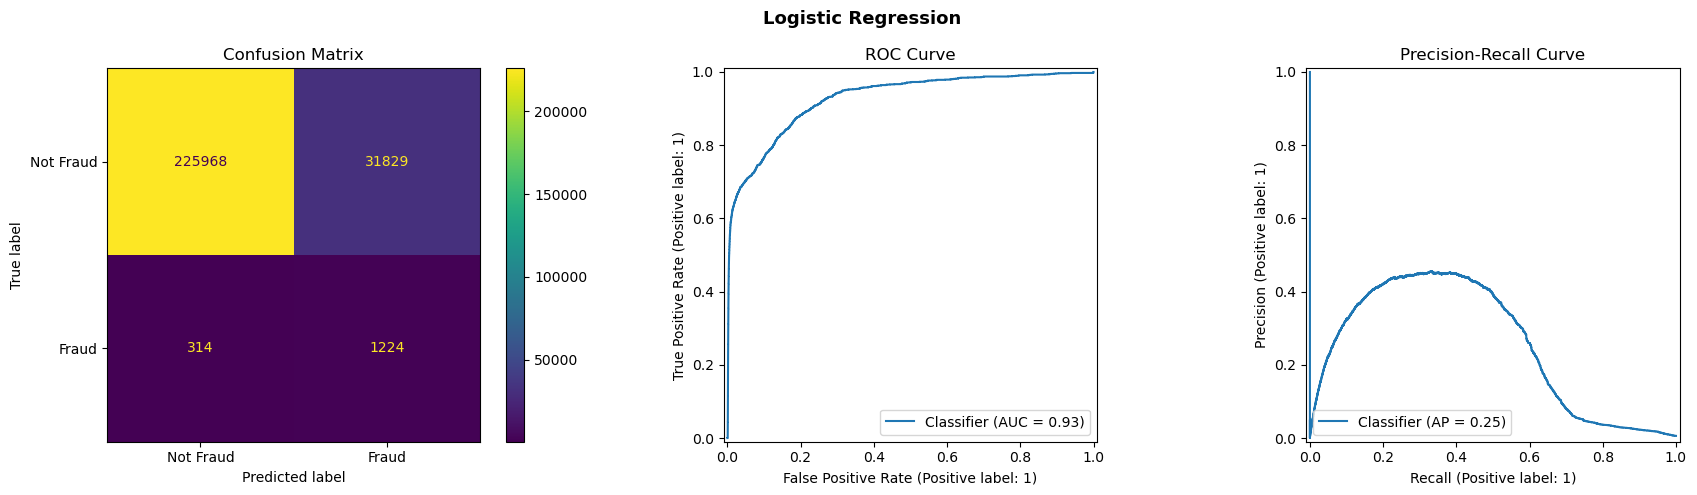

In [29]:
y_proba_lr = pipe.predict_proba(X_val)[:, 1]
evaluate_model(y_val, y_proba_lr, "Logistic Regression")

## Supervised Advanced — LightGBM

LightGBM is a gradient-boosted tree framework optimised for large tabular datasets. It captures non-linear feature interactions natively without requiring manual transformations — `hour` is kept raw rather than cyclically encoded since tree splits handle the 23→0 boundary automatically. The `scale_pos_weight` parameter rebalances the positive class in proportion to the training class ratio. Early stopping on the validation set prevents overfitting beyond the optimal tree count.

### Feature Engineering

In [30]:
df_lgbm = df.copy()
df_lgbm = df_lgbm.sort_values(['cc_num', 'unix_time'])

df_lgbm['hours_since_last_trans'] = df_lgbm.groupby('cc_num')['unix_time'].diff() / 3600
df_lgbm['hours_since_last_trans'] = df_lgbm['hours_since_last_trans'].fillna(
    df_lgbm['hours_since_last_trans'].median()
)

df_lgbm['hour'] = df_lgbm['trans_date_trans_time'].dt.hour

_cat_mean = df[df['is_fraud'] == 0].groupby('category', observed=True)['amt'].mean()
_cat_std  = df[df['is_fraud'] == 0].groupby('category', observed=True)['amt'].std()

df_lgbm['amt_zscore_cat'] = (
    (df_lgbm['amt'] - df_lgbm['category'].map(_cat_mean))
    / (df_lgbm['category'].map(_cat_std) + 1e-6)
)

_g = df_lgbm.groupby('cc_num')['amt']
df_lgbm['amt_zscore_card'] = (
    (df_lgbm['amt'] - _g.transform(lambda x: x.expanding().mean().shift(1)))
    / (_g.transform(lambda x: x.expanding().std().shift(1)) + 1e-6)
).fillna(0)

cols_to_drop = ['trans_num', 'cc_num', 'first', 'last', 'gender',
                'street', 'city', 'state', 'zip', 'lat', 'long',
                'merch_lat', 'merch_long', 'city_pop', 'job',
                'merchant', 'unix_time', 'dob', 'trans_date_trans_time']
df_lgbm = df_lgbm.drop(columns=cols_to_drop)
df_lgbm['category'] = df_lgbm['category'].astype('category')  
df_lgbm = df_lgbm.sort_index()


### Preprocessing

In [31]:
X_lgbm = df_lgbm.drop(columns=['is_fraud'])
y_lgbm = df_lgbm['is_fraud']

X_train_lgbm, X_val_lgbm, y_train_lgbm, y_val_lgbm = train_test_split(X_lgbm, y_lgbm, test_size=0.2, shuffle=False)

scale_pos = (y_train_lgbm == 0).sum() / (y_train_lgbm == 1).sum()

lgbm = LGBMClassifier(
    n_estimators=500,
    learning_rate=0.05,
    scale_pos_weight=scale_pos,
    random_state=42,
    n_jobs=-1
)

lgbm.fit(
    X_train_lgbm, y_train_lgbm,
    categorical_feature=['category'],
    eval_set=[(X_val_lgbm, y_val_lgbm)],
    callbacks=[early_stopping(50, verbose=False), log_evaluation(100)]
)


[LightGBM] [Info] Number of positive: 5968, number of negative: 1031372
[LightGBM] [Info] Auto-choosing row-wise multi-threading, the overhead of testing was 0.011503 seconds.
You can set `force_row_wise=true` to remove the overhead.
And if memory is not enough, you can set `force_col_wise=true`.
[LightGBM] [Info] Total Bins 1059
[LightGBM] [Info] Number of data points in the train set: 1037340, number of used features: 6
[LightGBM] [Info] [binary:BoostFromScore]: pavg=0.005753 -> initscore=-5.152233
[LightGBM] [Info] Start training from score -5.152233
[100]	valid_0's binary_logloss: 0.043748
[200]	valid_0's binary_logloss: 0.035099
[300]	valid_0's binary_logloss: 0.030115
[400]	valid_0's binary_logloss: 0.0271491
[500]	valid_0's binary_logloss: 0.0241697


,boosting_type,'gbdt'
,num_leaves,31
,max_depth,-1
,learning_rate,0.05
,n_estimators,500
,subsample_for_bin,200000
,objective,None
,class_weight,None
,min_split_gain,0.0
,min_child_weight,0.001
,min_child_samples,20


### LightGBM - Model evalutation 


════════════════════════════════════════════
  LightGBM
────────────────────────────────────────────
  PR-AUC  (primary)   0.8987
  ROC-AUC             0.9977
────────────────────────────────────────────
              precision    recall  f1-score   support

   Not Fraud       1.00      0.99      1.00    257797
       Fraud       0.38      0.96      0.55      1538

    accuracy                           0.99    259335
   macro avg       0.69      0.97      0.77    259335
weighted avg       1.00      0.99      0.99    259335

════════════════════════════════════════════



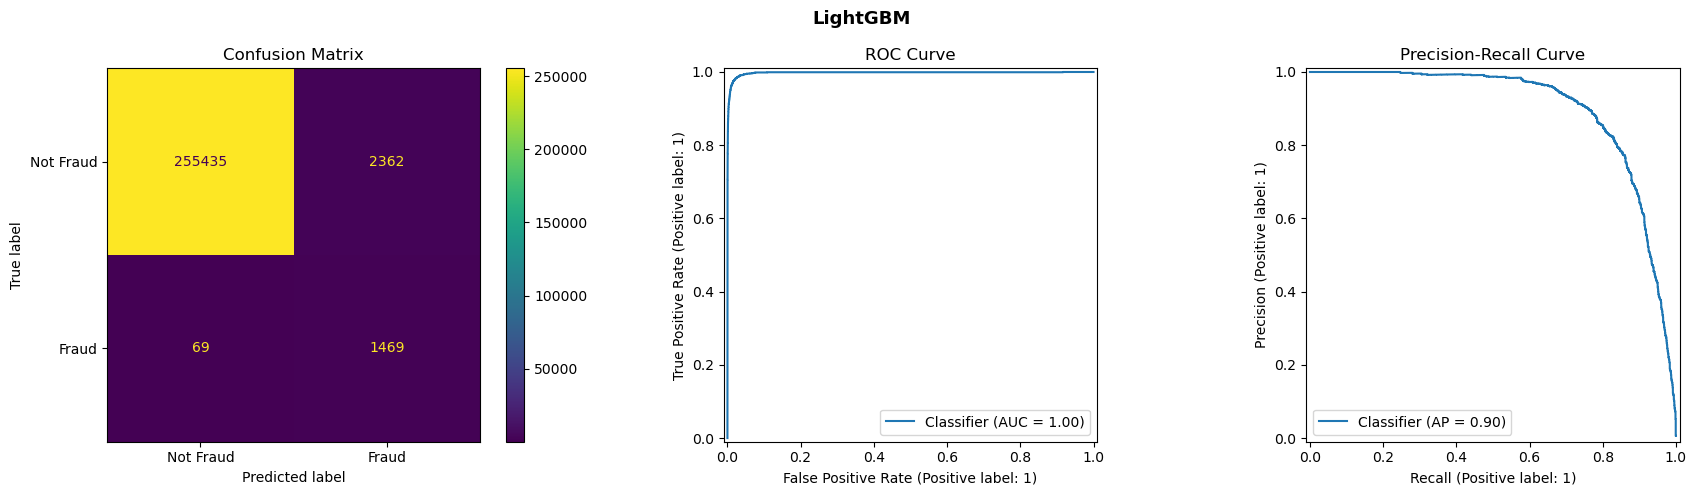

In [32]:
y_proba_lgbm = lgbm.predict_proba(X_val_lgbm)[:, 1]
evaluate_model(y_val_lgbm, y_proba_lgbm, "LightGBM")

### Fase 1 — Summary

With full labels, the supervised approach dominates. **PR-AUC is the primary metric** throughout this project: on a ~0.58% fraud rate, ROC-AUC is inflated by the easy negatives, while PR-AUC measures precision-recall trade-offs directly on the minority class.

LightGBM establishes the supervised ceiling; Logistic Regression quantifies the cost of linearity. Both require fraud labels to train — the question Fase 2 asks is: *how far can label-free methods reach?* Fase 3 then finds the exact label budget at which supervised becomes preferable.

## Fase 2 — Unsupervised Models

Without fraud labels, models must learn what *normal* looks like and flag deviations at inference time. We evaluate five architectures in order of increasing inductive bias:

1. **MixedAE** *(Section 2.1)* — per-transaction reconstruction with categorical embedding; no temporal context
2. **LSTM-AE** *(Section 2.2)* — sequential modelling via LSTM encoder; deterministic latent space
3. **GRU-AE** *(Section 2.3)* — same sequential approach with GRU cells; fewer parameters than LSTM
4. **Transformer-AE** *(Section 2.4)* — self-attention over card history; global context without sequential bias
5. **LSTM-VAE** *(Section 2.5)* — sequential modelling with a stochastic latent space; explicit uncertainty

**Design principle — identical features, no labels.** All five models share the same ten numerical features and one categorical feature across the same train/validation split. This makes the comparison a clean isolation of the architectural effect.

**Anomaly score convention:** every model outputs a scalar per transaction. The binary threshold is the 99.5th percentile of normal-transaction training scores; **PR-AUC** is the primary (threshold-independent) metric.

### Feature Engineering and Preprocessing

Ten numerical features and one categorical feature (`category`) are shared across all five Fase-2 models.

**Numerical features (10):**
- `amt` (log-scaled), `hours_since_last_trans` (log-scaled), `hour_sin`, `hour_cos`
- `amt_zscore_cat`, `amt_zscore_card` — category- and card-level z-scores, leakage-safe
- `n_prev_tx_card` — card history depth (log-scaled)
- `is_online` — 1 if category ends with *_net*
- `is_night` — 1 if transaction hour ∈ {22, 23, 0, 1, 2}
- `geo_velocity` — km/h between consecutive merchants (log-scaled, capped at 10,000)

**Preprocessing:** `log1p` on right-skewed features, then `StandardScaler` fitted on *normal transactions only*. Binary features (`is_online`, `is_night`) pass through StandardScaler as-is. Distributional extremes are preserved so anomalous values remain outliers after scaling.

In [ ]:
df_ae = df.copy()
df_ae = df_ae.sort_values(['cc_num', 'unix_time'])

# --- six base features ---
df_ae['hours_since_last_trans'] = df_ae.groupby('cc_num')['unix_time'].diff() / 3600
df_ae['hours_since_last_trans'] = df_ae['hours_since_last_trans'].fillna(
    df_ae['hours_since_last_trans'].median()
)

_hour = df_ae['trans_date_trans_time'].dt.hour
df_ae['hour_sin'] = np.sin(2 * np.pi * _hour / 24)
df_ae['hour_cos'] = np.cos(2 * np.pi * _hour / 24)

_cat_mean = df[df['is_fraud'] == 0].groupby('category', observed=True)['amt'].mean()
_cat_std  = df[df['is_fraud'] == 0].groupby('category', observed=True)['amt'].std()
df_ae['amt_zscore_cat'] = (
    (df_ae['amt'] - df_ae['category'].map(_cat_mean))
    / (df_ae['category'].map(_cat_std) + 1e-6)
)

_g = df_ae.groupby('cc_num')['amt']
df_ae['amt_zscore_card'] = (
    (df_ae['amt'] - _g.transform(lambda x: x.expanding().mean().shift(1)))
    / (_g.transform(lambda x: x.expanding().std().shift(1)) + 1e-6)
).fillna(0)

# --- four new features ---

# Card history depth
df_ae['n_prev_tx_card'] = df_ae.groupby('cc_num').cumcount()

# Binary flags: online channel and nighttime window
df_ae['is_online'] = df_ae['category'].str.endswith('_net').astype(np.float32)
df_ae['is_night']  = _hour.isin([22, 23, 0, 1, 2]).astype(np.float32)

# Geographic velocity (km/h between consecutive merchant locations)
df_ae['prev_mlat']  = df_ae.groupby('cc_num')['merch_lat'].shift(1)
df_ae['prev_mlong'] = df_ae.groupby('cc_num')['merch_long'].shift(1)
_dt_h  = df_ae.groupby('cc_num')['unix_time'].diff() / 3600
_dist  = haversine_distance(
    df_ae['merch_lat'], df_ae['merch_long'],
    df_ae['prev_mlat'].fillna(df_ae['merch_lat']),
    df_ae['prev_mlong'].fillna(df_ae['merch_long'])
)
_valid = _dt_h.notna() & (_dt_h > 0)
df_ae['geo_velocity'] = 0.0
df_ae.loc[_valid, 'geo_velocity'] = (_dist[_valid] / _dt_h[_valid]).clip(upper=10000)
df_ae.drop(columns=['prev_mlat', 'prev_mlong'], inplace=True)

cols_to_drop = [
    'trans_num', 'cc_num', 'first', 'last', 'gender',
    'street', 'city', 'state', 'zip', 'lat', 'long',
    'merch_lat', 'merch_long', 'city_pop', 'job',
    'merchant', 'unix_time', 'dob', 'trans_date_trans_time'
]
df_ae = df_ae.drop(columns=cols_to_drop).sort_index()

### Preprocessing

In [ ]:
NUM_FEATURES = ['amt', 'hours_since_last_trans', 'hour_sin', 'hour_cos',
                'amt_zscore_cat', 'amt_zscore_card',
                'n_prev_tx_card', 'is_online', 'is_night', 'geo_velocity']
LOG_FEATURES = ['amt', 'hours_since_last_trans', 'n_prev_tx_card', 'geo_velocity']
CAT_FEATURES = ['category']
EMB_DIMS     = {'category': 4}

X_ae = df_ae.drop(columns=['is_fraud'])
y_ae = df_ae['is_fraud']

X_train_ae, X_val_ae, y_train_ae, y_val_ae = train_test_split(
    X_ae, y_ae, test_size=0.2, shuffle=False
)
X_train_normal = X_train_ae[y_train_ae == 0].copy()

_X_tr = X_train_normal[NUM_FEATURES].copy()
_X_tr[LOG_FEATURES] = np.log1p(_X_tr[LOG_FEATURES])
ss_ae = StandardScaler()
ss_ae.fit(_X_tr)

def preprocess_num(df_sub):
    X = df_sub[NUM_FEATURES].copy()
    X[LOG_FEATURES] = np.log1p(X[LOG_FEATURES])
    return ss_ae.transform(X).astype(np.float32)

X_train_num = preprocess_num(X_train_normal)
X_val_num   = preprocess_num(X_val_ae)

cat_vocabs      = {}
cat_vocab_sizes = {}
for col in CAT_FEATURES:
    vals = sorted(X_train_normal[col].dropna().unique())
    cat_vocabs[col]      = {v: i + 1 for i, v in enumerate(vals)}
    cat_vocab_sizes[col] = len(vals) + 1

def encode_cats(df_sub, vocabs, cols):
    arr = np.zeros((len(df_sub), len(cols)), dtype=np.int64)
    for j, col in enumerate(cols):
        arr[:, j] = df_sub[col].map(vocabs[col]).fillna(0).astype(int).values
    return arr

### 2.1 — MixedAE

The per-transaction baseline. Two structural upgrades over the original Vanilla AE:

1. **`category` is embedded** (dim 4) and concatenated with the 10 numerical features → input dimension 14
2. **Deeper architecture** — three encoder layers (14 → 64 → 32 → 12) and symmetric decoder

This gives the model enough capacity to learn non-trivial normal-transaction representations while remaining memoryless (no card history). Any gain from Sections 2.2–2.5 is attributable to temporal context alone.

#### Architecture

Mixed-input encoder-decoder: category embedding (dim 4) + 10 scaled numerical features → 14-dimensional input.

- **Encoder:** 14 → 64 → 32 → 12 (latent), ReLU activations
- **Decoder:** 12 → 32 → 64 → split into `num_head` (→ 10) and `cat_heads`
- **Loss:** `CONT_WEIGHT × MSE_num + (1 − CONT_WEIGHT) × CE_cat`
- **Anomaly score:** same combined loss evaluated per transaction at inference

In [ ]:
CONT_WEIGHT_AE = 0.75

class MixedAE(nn.Module):
    def __init__(self, n_num, vocab_sizes, emb_dims, cat_cols, latent_dim=12, hidden_dim=64):
        super().__init__()
        self.cat_cols   = cat_cols
        self.embeddings = nn.ModuleList([
            nn.Embedding(vocab_sizes[col], emb_dims[col]) for col in cat_cols
        ])
        emb_total = sum(emb_dims[col] for col in cat_cols)
        inp = n_num + emb_total
        self.encoder = nn.Sequential(
            nn.Linear(inp, hidden_dim), nn.ReLU(),
            nn.Linear(hidden_dim, hidden_dim // 2), nn.ReLU(),
            nn.Linear(hidden_dim // 2, latent_dim),
        )
        self.decoder = nn.Sequential(
            nn.Linear(latent_dim, hidden_dim // 2), nn.ReLU(),
            nn.Linear(hidden_dim // 2, hidden_dim), nn.ReLU(),
        )
        self.num_head  = nn.Linear(hidden_dim, n_num)
        self.cat_heads = nn.ModuleList([
            nn.Linear(hidden_dim, vocab_sizes[col]) for col in cat_cols
        ])

    def forward(self, x_num, x_cat):
        embs = [self.embeddings[i](x_cat[:, i]) for i in range(len(self.cat_cols))]
        x    = torch.cat(embs + [x_num], dim=1)
        h    = self.decoder(self.encoder(x))
        return self.num_head(h), [head(h) for head in self.cat_heads]

#### Training

`MSE` for the 10 continuous features and `cross-entropy` for `category`, combined with `CONT_WEIGHT_AE = 0.75`. Trained on normal transactions only; 50 epochs. Gradient clipping at max-norm 1.0.

In [ ]:
torch.manual_seed(42)
EPOCHS_MAE = 50

X_tr_cat_t  = torch.LongTensor(encode_cats(X_train_normal, cat_vocabs, CAT_FEATURES))
X_val_cat_t = torch.LongTensor(encode_cats(X_val_ae, cat_vocabs, CAT_FEATURES))
X_tr_num_t  = torch.FloatTensor(X_train_num)
X_val_num_t = torch.FloatTensor(X_val_num)
y_val_np    = y_val_ae.values

loader_mae = DataLoader(TensorDataset(X_tr_num_t, X_tr_cat_t), batch_size=256, shuffle=True)

model_mae = MixedAE(n_num=len(NUM_FEATURES), vocab_sizes=cat_vocab_sizes,
                    emb_dims=EMB_DIMS, cat_cols=CAT_FEATURES)
opt_mae   = optim.Adam(model_mae.parameters(), lr=1e-3)

losses_mae = []
model_mae.train()
for epoch in range(EPOCHS_MAE):
    ep = []
    for x_num_b, x_cat_b in loader_mae:
        x_hat, cat_logits = model_mae(x_num_b, x_cat_b)
        mse  = F.mse_loss(x_hat, x_num_b)
        ce   = torch.stack([
            F.cross_entropy(cat_logits[j], x_cat_b[:, j])
            for j in range(x_cat_b.shape[1])
        ]).mean()
        loss = CONT_WEIGHT_AE * mse + (1 - CONT_WEIGHT_AE) * ce
        opt_mae.zero_grad(); loss.backward()
        torch.nn.utils.clip_grad_norm_(model_mae.parameters(), max_norm=1.0)
        opt_mae.step()
        ep.append(loss.item())
    losses_mae.append(np.mean(ep))
    if (epoch + 1) % 10 == 0:
        print(f"Epoch {epoch+1:2d}/{EPOCHS_MAE} — loss: {losses_mae[-1]:.6f}")

plt.plot(losses_mae)
plt.xlabel('Epoch'); plt.ylabel('Loss'); plt.title('MixedAE — Training Loss')
plt.show()

#### Evaluation

In [ ]:
def threshold_from_normal_scores(scores_normal, percentile=99.5):
    return float(np.percentile(scores_normal, percentile))

model_mae.eval()
with torch.no_grad():
    def _score_mae(xn_t, xc_t):
        out = []
        for i in range(0, len(xn_t), 2048):
            xn, xc = xn_t[i:i+2048], xc_t[i:i+2048]
            xn_hat, cat_logits = model_mae(xn, xc)
            mse = F.mse_loss(xn_hat, xn, reduction='none').mean(dim=1)
            ce  = torch.stack([
                F.cross_entropy(cat_logits[j], xc[:, j], reduction='none')
                for j in range(xc.shape[1])
            ], dim=1).mean(dim=1)
            out.append((CONT_WEIGHT_AE * mse + (1 - CONT_WEIGHT_AE) * ce).cpu())
        return torch.cat(out).numpy()

    scores_mae_tr  = _score_mae(X_tr_num_t, X_tr_cat_t)
    scores_mae_val = _score_mae(X_val_num_t, X_val_cat_t)

thr_mae = threshold_from_normal_scores(scores_mae_tr, percentile=99.5)
evaluate_model(y_val_np, scores_mae_val, "MixedAE", threshold=thr_mae)

#### MixedAE — Results

MixedAE is the per-transaction ceiling for memoryless models: it sees `category` via embedding and has direct access to `is_night` and `is_online` — the two strongest fraud-rate signals in the dataset. Any performance gap relative to Sections 2.2–2.5 is attributable to temporal context: the sequential models can detect that a transaction breaks a card's established pattern even when individual feature values are not extreme.

### 2.2–2.5 — Sequential Models: Shared Sequence Construction

Sections 2.2–2.5 all model each transaction as the final element in the card's recent history. For each transaction we build a window of length `SEQ_LEN = 10`: positions 0–8 contain the 9 most recent prior transactions on the same card (zero-padded at the start of the card's history), and position 9 contains the current transaction.

The sequence array is built once below and reused across LSTM-AE, GRU-AE, Transformer-AE, and LSTM-VAE. A shared `DataLoader` (`loader_seq`) is defined at the end of this cell.

In [ ]:
SEQ_LEN = 10

_meta = df.loc[df_ae.index, ['cc_num', 'unix_time']].copy()
_meta['_row'] = np.arange(len(_meta))

_all_num = preprocess_num(X_ae)
_all_cat = encode_cats(X_ae, cat_vocabs, CAT_FEATURES)

seq_num_all = np.zeros((len(_meta), SEQ_LEN, len(NUM_FEATURES)), dtype=np.float32)
seq_cat_all = np.zeros((len(_meta), SEQ_LEN, len(CAT_FEATURES)), dtype=np.int64)

for cc, grp in _meta.sort_values(['cc_num', 'unix_time']).groupby('cc_num', sort=False):
    rows = grp['_row'].values
    for k, pos in enumerate(rows):
        start  = max(0, k - SEQ_LEN + 1)
        window = rows[start:k + 1]
        offset = SEQ_LEN - len(window)
        seq_num_all[pos, offset:] = _all_num[window]
        seq_cat_all[pos, offset:] = _all_cat[window]

n_tr           = len(X_train_ae)
_tr_normal_pos = np.where(y_ae.values[:n_tr] == 0)[0]

_rng = np.random.default_rng(42)
if len(_tr_normal_pos) > 200_000:
    _tr_normal_pos = np.sort(_rng.choice(_tr_normal_pos, size=200_000, replace=False))

seq_num_tr_t  = torch.FloatTensor(seq_num_all[_tr_normal_pos])
seq_cat_tr_t  = torch.LongTensor(seq_cat_all[_tr_normal_pos])
seq_num_val_t = torch.FloatTensor(seq_num_all[n_tr:])
seq_cat_val_t = torch.LongTensor(seq_cat_all[n_tr:])

# Shared DataLoader — reused by LSTM-AE, GRU-AE, Transformer-AE, and LSTM-VAE
CONT_WEIGHT_SEQ = 0.75
EPOCHS_SEQ      = 60
loader_seq = DataLoader(TensorDataset(seq_num_tr_t, seq_cat_tr_t),
                        batch_size=256, shuffle=True)

### 2.2 — LSTM-AE

**Architecture:** LSTM reads the 9-step history (positions 0–8) and produces a hidden state `h`. An MLP decoder projects `h` to predict the current transaction (position 9) via Gaussian NLL (continuous features) and cross-entropy (categorical). No stochastic component — this is the deterministic sequential baseline.

Using NLL rather than MSE allows the decoder to output per-feature uncertainty (log σ), making the anomaly score directly comparable to the probabilistic LSTM-VAE in Section 2.5.

**Why LSTM-AE before LSTM-VAE?** Comparing these two isolates the effect of the stochastic latent space: same architecture, same loss structure, only the VAE bottleneck differs.

In [39]:
def mixed_nll_loss(x_num, x_cat, mu, log_sigma, cat_logits, cont_weight):
    """Gaussian NLL (continuous) + cross-entropy (categorical), weighted sum."""
    sigma    = log_sigma.exp()
    nll_cont = (log_sigma + 0.5 * ((x_num - mu) / sigma) ** 2).sum(dim=1).mean()
    nll_cat  = torch.stack([
        F.cross_entropy(cat_logits[j], x_cat[:, j], reduction='none')
        for j in range(x_cat.shape[1])
    ], dim=1).sum(dim=1).mean()
    return cont_weight * nll_cont + (1 - cont_weight) * nll_cat


def score_seq_ae(model, seq_num_t, seq_cat_t, cont_weight, batch_size=2048):
    """Generic scoring for deterministic sequential models (LSTM-AE, GRU-AE, Transformer-AE)."""
    model.eval()
    scores = []
    with torch.no_grad():
        for i in range(0, len(seq_num_t), batch_size):
            sn, sc  = seq_num_t[i:i + batch_size], seq_cat_t[i:i + batch_size]
            xn_last, xc_last = sn[:, -1, :], sc[:, -1, :]
            mu, log_sigma, cat_logits = model(sn, sc)
            sigma  = log_sigma.exp()
            s_cont = (log_sigma + 0.5 * ((xn_last - mu) / sigma) ** 2).sum(dim=1)
            s_cat  = torch.stack([
                F.cross_entropy(cat_logits[j], xc_last[:, j], reduction='none')
                for j in range(xc_last.shape[1])
            ], dim=1).sum(dim=1)
            scores.append((cont_weight * s_cont + (1 - cont_weight) * s_cat).cpu())
    return torch.cat(scores).numpy()


class LSTMAE(nn.Module):
    def __init__(self, vocab_sizes, emb_dims, cat_cols, n_num, hidden_dim=64):
        super().__init__()
        self.cat_cols = cat_cols
        self.n_num    = n_num
        self.embeddings = nn.ModuleList([
            nn.Embedding(vocab_sizes[col], emb_dims[col]) for col in cat_cols
        ])
        input_dim = n_num + sum(emb_dims[col] for col in cat_cols)
        self.lstm      = nn.LSTM(input_dim, hidden_dim, batch_first=True)
        self.decoder   = nn.Sequential(nn.Linear(hidden_dim, hidden_dim), nn.ReLU())
        self.cont_head = nn.Linear(hidden_dim, n_num * 2)
        self.cat_heads = nn.ModuleList([
            nn.Linear(hidden_dim, vocab_sizes[col]) for col in cat_cols
        ])

    def forward(self, x_num_seq, x_cat_seq):
        embs = [self.embeddings[i](x_cat_seq[:, :, i]) for i in range(len(self.cat_cols))]
        x    = torch.cat(embs + [x_num_seq], dim=2)
        _, (h, _) = self.lstm(x[:, :-1, :])   # read history, exclude current tx
        h    = h.squeeze(0)
        hd   = self.decoder(h)
        cont = self.cont_head(hd)
        return cont[:, :self.n_num], cont[:, self.n_num:].clamp(-5, 2), [head(hd) for head in self.cat_heads]

#### Training

Gaussian NLL loss (continuous) + cross-entropy (categorical), `CONT_WEIGHT_SEQ = 0.75`. Trained on the shared normal-transaction sequences for `EPOCHS_SEQ = 60` epochs. Gradient clipping at max-norm 1.0.

Epoch 10/60 — loss: 0.0675
Epoch 20/60 — loss: -0.3616
Epoch 30/60 — loss: -0.6321
Epoch 40/60 — loss: -0.7183
Epoch 50/60 — loss: -0.8268
Epoch 60/60 — loss: -0.9454


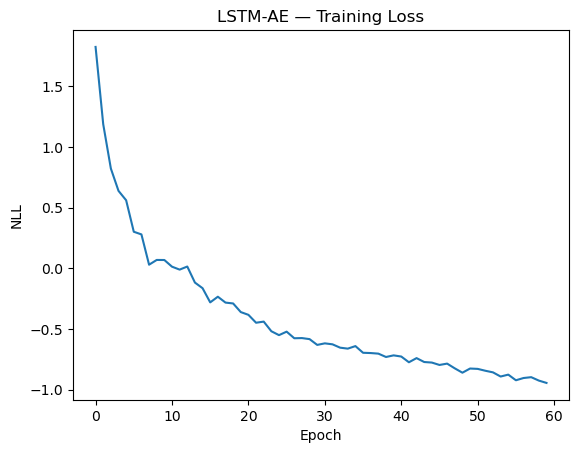

In [40]:
torch.manual_seed(42)
model_lstm_ae = LSTMAE(vocab_sizes=cat_vocab_sizes, emb_dims=EMB_DIMS,
                       cat_cols=CAT_FEATURES, n_num=len(NUM_FEATURES))
opt_lstm_ae   = optim.Adam(model_lstm_ae.parameters(), lr=1e-3)

losses_lstm_ae = []
model_lstm_ae.train()
for epoch in range(EPOCHS_SEQ):
    ep = []
    for x_num_seq, x_cat_seq in loader_seq:
        xn_last, xc_last = x_num_seq[:, -1, :], x_cat_seq[:, -1, :]
        mu, log_sigma, cat_logits = model_lstm_ae(x_num_seq, x_cat_seq)
        loss = mixed_nll_loss(xn_last, xc_last, mu, log_sigma, cat_logits, CONT_WEIGHT_SEQ)
        opt_lstm_ae.zero_grad(); loss.backward()
        torch.nn.utils.clip_grad_norm_(model_lstm_ae.parameters(), max_norm=1.0)
        opt_lstm_ae.step()
        ep.append(loss.item())
    losses_lstm_ae.append(np.mean(ep))
    if (epoch + 1) % 10 == 0:
        print(f"Epoch {epoch+1:2d}/{EPOCHS_SEQ} — loss: {losses_lstm_ae[-1]:.4f}")

plt.plot(losses_lstm_ae)
plt.xlabel('Epoch'); plt.ylabel('NLL'); plt.title('LSTM-AE — Training Loss')
plt.show()

#### Evaluation


════════════════════════════════════════════
  LSTM-AE
────────────────────────────────────────────
  PR-AUC  (primary)   0.2244
  ROC-AUC             0.9381
────────────────────────────────────────────
              precision    recall  f1-score   support

   Not Fraud       1.00      0.99      1.00    257797
       Fraud       0.34      0.44      0.38      1538

    accuracy                           0.99    259335
   macro avg       0.67      0.72      0.69    259335
weighted avg       0.99      0.99      0.99    259335

════════════════════════════════════════════



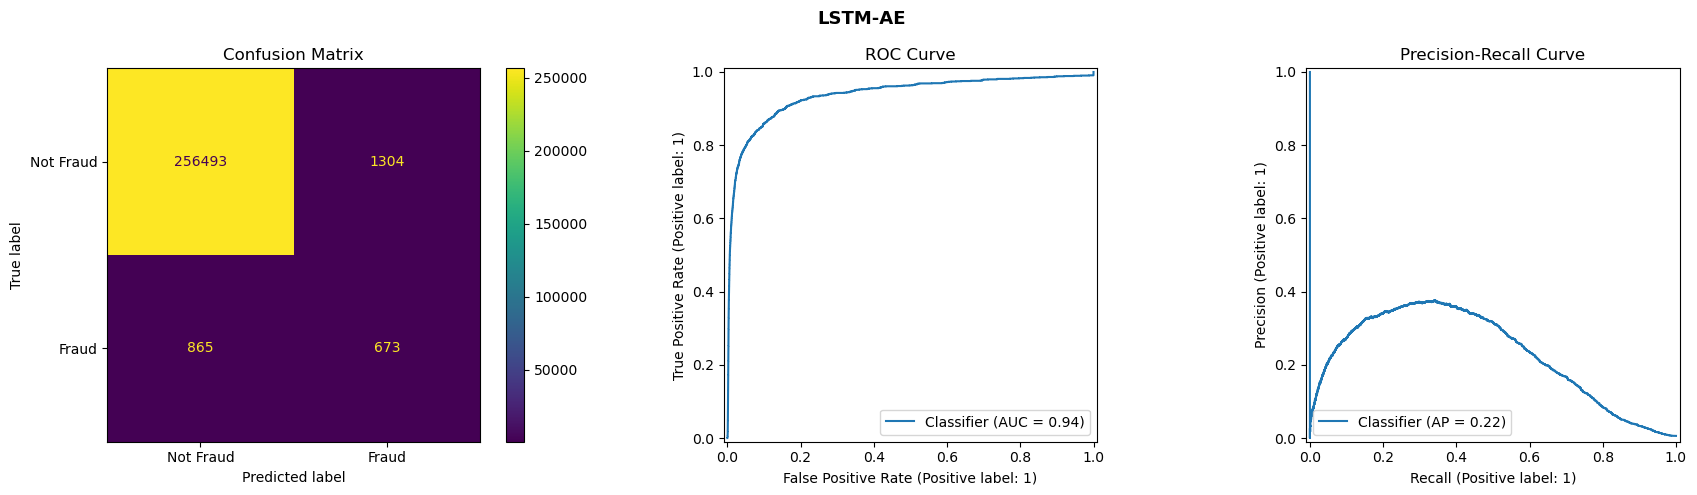

In [41]:
scores_lstm_ae_tr  = score_seq_ae(model_lstm_ae, seq_num_tr_t,  seq_cat_tr_t,  CONT_WEIGHT_SEQ)
scores_lstm_ae_val = score_seq_ae(model_lstm_ae, seq_num_val_t, seq_cat_val_t, CONT_WEIGHT_SEQ)

thr_lstm_ae = threshold_from_normal_scores(scores_lstm_ae_tr, percentile=99.5)
evaluate_model(y_val_ae.values, scores_lstm_ae_val, "LSTM-AE", threshold=thr_lstm_ae)

#### LSTM-AE — Results

The LSTM-AE processes each card's transaction history sequentially. Any improvement over MixedAE (Section 2.1) is due to temporal context: the model has learned what a typical *sequence* of transactions on this card looks like, not just what individual transaction values look like in isolation.

### 2.3 — GRU-AE

Identical to LSTM-AE but replacing the LSTM cell with a **GRU** (Gated Recurrent Unit).

**Architectural difference:** GRU merges the forget and input gates into a single update gate and has no separate cell state, reducing the parameter count by ~25% for the same hidden dimension. On short-to-medium sequences (here, 9 steps), GRU empirically matches LSTM performance while training faster.

This section answers: *does the richer LSTM cell state add anything for this task, or does the simpler GRU suffice?*

In [42]:
class GRUAE(nn.Module):
    """Architecture identical to LSTMAE — GRU instead of LSTM, no cell state."""
    def __init__(self, vocab_sizes, emb_dims, cat_cols, n_num, hidden_dim=64):
        super().__init__()
        self.cat_cols = cat_cols
        self.n_num    = n_num
        self.embeddings = nn.ModuleList([
            nn.Embedding(vocab_sizes[col], emb_dims[col]) for col in cat_cols
        ])
        input_dim = n_num + sum(emb_dims[col] for col in cat_cols)
        self.gru       = nn.GRU(input_dim, hidden_dim, batch_first=True)
        self.decoder   = nn.Sequential(nn.Linear(hidden_dim, hidden_dim), nn.ReLU())
        self.cont_head = nn.Linear(hidden_dim, n_num * 2)
        self.cat_heads = nn.ModuleList([
            nn.Linear(hidden_dim, vocab_sizes[col]) for col in cat_cols
        ])

    def forward(self, x_num_seq, x_cat_seq):
        embs = [self.embeddings[i](x_cat_seq[:, :, i]) for i in range(len(self.cat_cols))]
        x    = torch.cat(embs + [x_num_seq], dim=2)
        _, h = self.gru(x[:, :-1, :])   # GRU: returns (output, h_n), no cell state
        h    = h.squeeze(0)
        hd   = self.decoder(h)
        cont = self.cont_head(hd)
        return cont[:, :self.n_num], cont[:, self.n_num:].clamp(-5, 2), [head(hd) for head in self.cat_heads]

Epoch 10/60 — loss: -0.1249
Epoch 20/60 — loss: -0.5159
Epoch 30/60 — loss: -0.6516
Epoch 40/60 — loss: -0.7907
Epoch 50/60 — loss: -0.9528
Epoch 60/60 — loss: -1.0008


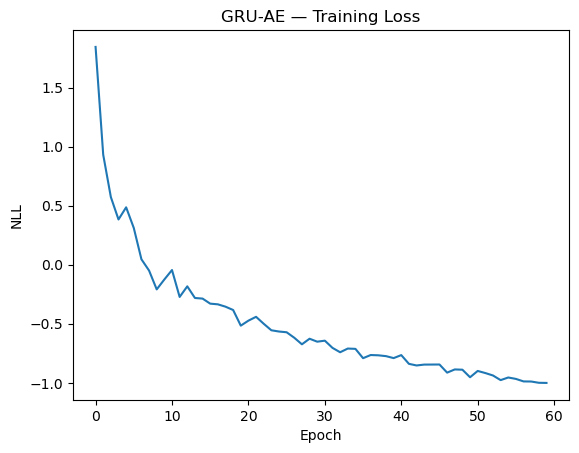

In [43]:
torch.manual_seed(42)
model_gru_ae = GRUAE(vocab_sizes=cat_vocab_sizes, emb_dims=EMB_DIMS,
                     cat_cols=CAT_FEATURES, n_num=len(NUM_FEATURES))
opt_gru_ae   = optim.Adam(model_gru_ae.parameters(), lr=1e-3)

losses_gru_ae = []
model_gru_ae.train()
for epoch in range(EPOCHS_SEQ):
    ep = []
    for x_num_seq, x_cat_seq in loader_seq:
        xn_last, xc_last = x_num_seq[:, -1, :], x_cat_seq[:, -1, :]
        mu, log_sigma, cat_logits = model_gru_ae(x_num_seq, x_cat_seq)
        loss = mixed_nll_loss(xn_last, xc_last, mu, log_sigma, cat_logits, CONT_WEIGHT_SEQ)
        opt_gru_ae.zero_grad(); loss.backward()
        torch.nn.utils.clip_grad_norm_(model_gru_ae.parameters(), max_norm=1.0)
        opt_gru_ae.step()
        ep.append(loss.item())
    losses_gru_ae.append(np.mean(ep))
    if (epoch + 1) % 10 == 0:
        print(f"Epoch {epoch+1:2d}/{EPOCHS_SEQ} — loss: {losses_gru_ae[-1]:.4f}")

plt.plot(losses_gru_ae)
plt.xlabel('Epoch'); plt.ylabel('NLL'); plt.title('GRU-AE — Training Loss')
plt.show()

#### Evaluation


════════════════════════════════════════════
  GRU-AE
────────────────────────────────────────────
  PR-AUC  (primary)   0.2727
  ROC-AUC             0.9389
────────────────────────────────────────────
              precision    recall  f1-score   support

   Not Fraud       1.00      0.99      1.00    257797
       Fraud       0.33      0.50      0.40      1538

    accuracy                           0.99    259335
   macro avg       0.66      0.75      0.70    259335
weighted avg       0.99      0.99      0.99    259335

════════════════════════════════════════════



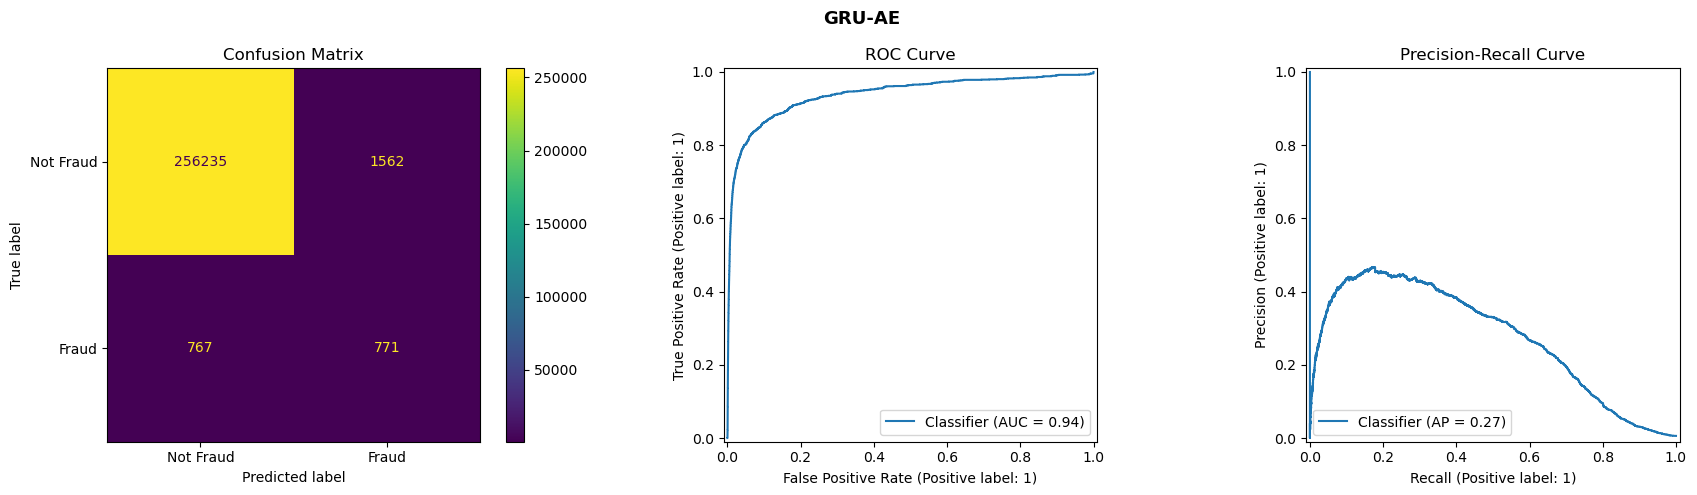

In [44]:
scores_gru_ae_tr  = score_seq_ae(model_gru_ae, seq_num_tr_t,  seq_cat_tr_t,  CONT_WEIGHT_SEQ)
scores_gru_ae_val = score_seq_ae(model_gru_ae, seq_num_val_t, seq_cat_val_t, CONT_WEIGHT_SEQ)

thr_gru_ae = threshold_from_normal_scores(scores_gru_ae_tr, percentile=99.5)
evaluate_model(y_val_ae.values, scores_gru_ae_val, "GRU-AE", threshold=thr_gru_ae)

#### GRU-AE — Results

Comparing GRU-AE to LSTM-AE under identical training conditions isolates the effect of the cell state. Similar PR-AUC would suggest the task does not require the long-term memory LSTM provides over these 9-step windows; a gap would argue for keeping the richer architecture.

### 2.4 — Transformer-AE

**Key architectural difference from LSTM/GRU:** the Transformer encoder applies **multi-head self-attention** across all 9 history steps simultaneously, rather than processing them sequentially. This allows the model to attend globally — for example, recognising that a small test charge 7 steps ago and the current large charge form a coherent fraud pattern, even if the intermediate transactions are unremarkable.

Architecture:
- **Input projection:** each of the 9 history steps is mapped from `input_dim` → `d_model = 64`
- **Positional encoding:** learnable embedding (9 positions)
- **Transformer encoder:** 2 layers, 4 attention heads, feed-forward dim 128, dropout 0.1
- **Pooling:** last position output is used as the sequence summary (analogous to the LSTM hidden state at the final step)
- **Decoder:** same MLP structure as LSTM-AE → predicts current transaction

In [45]:
class TransformerAE(nn.Module):
    def __init__(self, vocab_sizes, emb_dims, cat_cols, n_num,
                 d_model=64, nhead=4, num_layers=2, dropout=0.1):
        super().__init__()
        self.cat_cols = cat_cols
        self.n_num    = n_num
        self.embeddings = nn.ModuleList([
            nn.Embedding(vocab_sizes[col], emb_dims[col]) for col in cat_cols
        ])
        input_dim = n_num + sum(emb_dims[col] for col in cat_cols)
        self.input_proj = nn.Linear(input_dim, d_model)
        self.pos_emb    = nn.Embedding(SEQ_LEN, d_model)

        enc_layer = nn.TransformerEncoderLayer(
            d_model=d_model, nhead=nhead, dim_feedforward=d_model * 2,
            dropout=dropout, batch_first=True
        )
        self.transformer = nn.TransformerEncoder(enc_layer, num_layers=num_layers)

        self.decoder   = nn.Sequential(nn.Linear(d_model, d_model), nn.ReLU())
        self.cont_head = nn.Linear(d_model, n_num * 2)
        self.cat_heads = nn.ModuleList([
            nn.Linear(d_model, vocab_sizes[col]) for col in cat_cols
        ])

    def forward(self, x_num_seq, x_cat_seq):
        T = x_num_seq.shape[1] - 1                  # history length = SEQ_LEN - 1
        embs = [self.embeddings[i](x_cat_seq[:, :T, i]) for i in range(len(self.cat_cols))]
        x    = torch.cat(embs + [x_num_seq[:, :T, :]], dim=2)   # [B, T, input_dim]
        x    = self.input_proj(x)                                 # [B, T, d_model]
        pos  = torch.arange(T, device=x.device)
        x    = x + self.pos_emb(pos)                             # add positional encoding
        x    = self.transformer(x)                               # [B, T, d_model]
        h    = x[:, -1, :]                                       # last position as summary
        hd   = self.decoder(h)
        cont = self.cont_head(hd)
        return cont[:, :self.n_num], cont[:, self.n_num:].clamp(-5, 2), [head(hd) for head in self.cat_heads]

#### Training

Same loss and hyperparameters as LSTM-AE and GRU-AE.

In [46]:
torch.manual_seed(42)
model_transf = TransformerAE(vocab_sizes=cat_vocab_sizes, emb_dims=EMB_DIMS,
                              cat_cols=CAT_FEATURES, n_num=len(NUM_FEATURES))
opt_transf   = optim.Adam(model_transf.parameters(), lr=1e-3)

losses_transf = []
model_transf.train()
for epoch in range(EPOCHS_SEQ):
    ep = []
    for x_num_seq, x_cat_seq in loader_seq:
        xn_last, xc_last = x_num_seq[:, -1, :], x_cat_seq[:, -1, :]
        mu, log_sigma, cat_logits = model_transf(x_num_seq, x_cat_seq)
        loss = mixed_nll_loss(xn_last, xc_last, mu, log_sigma, cat_logits, CONT_WEIGHT_SEQ)
        opt_transf.zero_grad(); loss.backward()
        torch.nn.utils.clip_grad_norm_(model_transf.parameters(), max_norm=1.0)
        opt_transf.step()
        ep.append(loss.item())
    losses_transf.append(np.mean(ep))
    if (epoch + 1) % 10 == 0:
        print(f"Epoch {epoch+1:2d}/{EPOCHS_SEQ} — loss: {losses_transf[-1]:.4f}")

plt.plot(losses_transf)
plt.xlabel('Epoch'); plt.ylabel('NLL'); plt.title('Transformer-AE — Training Loss')
plt.show()

Epoch 10/60 — loss: 0.1715
Epoch 20/60 — loss: -0.1321


KeyboardInterrupt: 

#### Evaluation

In [ ]:
scores_transf_tr  = score_seq_ae(model_transf, seq_num_tr_t,  seq_cat_tr_t,  CONT_WEIGHT_SEQ)
scores_transf_val = score_seq_ae(model_transf, seq_num_val_t, seq_cat_val_t, CONT_WEIGHT_SEQ)

thr_transf = threshold_from_normal_scores(scores_transf_tr, percentile=99.5)
evaluate_model(y_val_ae.values, scores_transf_val, "Transformer-AE", threshold=thr_transf)

#### Transformer-AE — Results

The Transformer-AE applies global self-attention over the 9-step card history. Comparing to LSTM-AE and GRU-AE isolates the inductive bias: recurrent models process steps sequentially (recent steps naturally dominate), while the Transformer can attend to any step equally. For fraud patterns that involve non-adjacent anomalies (e.g., a test charge buried in legitimate history), the Transformer's global attention should be advantageous.

### 2.5 — LSTM-VAE

The LSTM-VAE extends LSTM-AE (Section 2.2) by introducing a **stochastic latent space**. The LSTM hidden state is projected to a Gaussian posterior q(z | history) via two linear heads (μ_z, log σ_z); a sample z is drawn and passed to the decoder.

The ELBO objective — reconstruction NLL + β · KL(q ‖ N(0,I)) — encourages the latent space to form a compact, continuous representation of normal card behaviour. At inference, transactions anomalous given the card's pattern produce high reconstruction NLL.

**Anomaly score:** prediction NLL of the current transaction conditioned on the encoded history (z = posterior mean at inference for stability).

In [ ]:
def mixed_nll_loss(x_num, x_cat, mu, log_sigma, cat_logits, cont_weight):
    """Gaussian NLL for continuous features + cross-entropy for categorical."""
    sigma    = log_sigma.exp()
    nll_cont = (log_sigma + 0.5 * ((x_num - mu) / sigma) ** 2).sum(dim=1).mean()
    nll_cat  = torch.stack([
        F.cross_entropy(cat_logits[j], x_cat[:, j], reduction='none')
        for j in range(x_cat.shape[1])
    ], dim=1).sum(dim=1).mean()
    return cont_weight * nll_cont + (1 - cont_weight) * nll_cat


class LSTMVAE(nn.Module):
    def __init__(self, vocab_sizes, emb_dims, cat_cols, n_num,
                 hidden_dim=64, latent_dim=16):
        super().__init__()
        self.cat_cols = cat_cols
        self.n_num    = n_num

        self.embeddings = nn.ModuleList([
            nn.Embedding(vocab_sizes[col], emb_dims[col]) for col in cat_cols
        ])
        input_dim = n_num + sum(emb_dims[col] for col in cat_cols)

        self.lstm         = nn.LSTM(input_dim, hidden_dim, batch_first=True)
        self.fc_mu        = nn.Linear(hidden_dim, latent_dim)
        self.fc_log_sigma = nn.Linear(hidden_dim, latent_dim)

        self.decoder   = nn.Sequential(nn.Linear(latent_dim, hidden_dim), nn.ReLU())
        self.cont_head = nn.Linear(hidden_dim, n_num * 2)
        self.cat_heads = nn.ModuleList([
            nn.Linear(hidden_dim, vocab_sizes[col]) for col in cat_cols
        ])

    def encode(self, x_num_seq, x_cat_seq):
        embs = [self.embeddings[i](x_cat_seq[:, :, i]) for i in range(len(self.cat_cols))]
        x    = torch.cat(embs + [x_num_seq], dim=2)
        _, (h, _) = self.lstm(x[:, :-1, :])
        h = h.squeeze(0)
        return self.fc_mu(h), self.fc_log_sigma(h).clamp(-4, 2)

    def decode(self, z):
        h         = self.decoder(z)
        cont      = self.cont_head(h)
        mu        = cont[:, :self.n_num]
        log_sigma = cont[:, self.n_num:].clamp(-5, 2)
        return mu, log_sigma, [head(h) for head in self.cat_heads]

    def forward(self, x_num_seq, x_cat_seq):
        mu_z, log_sigma_z = self.encode(x_num_seq, x_cat_seq)
        z = mu_z + torch.randn_like(mu_z) * log_sigma_z.exp() if self.training else mu_z
        mu_x, log_sigma_x, cat_logits = self.decode(z)
        return mu_x, log_sigma_x, cat_logits, mu_z, log_sigma_z

#### Training

`CONT_WEIGHT=0.75`, `β=0.1` with **KL warmup**: β is linearly annealed from 0 to `BETA` over the first `KL_WARMUP=20` epochs. This prevents posterior collapse — if the KL term is too strong early in training, the encoder learns to ignore the input and map everything to the prior N(0,I), producing a useless latent space. Warming up lets the reconstruction loss stabilise first. Gradient clipping at max norm 1.0 prevents exploding gradients in the LSTM. Training uses 200k randomly sampled normal transactions.

In [ ]:
torch.manual_seed(42)
CONT_WEIGHT = 0.75
BETA        = 0.1
EPOCHS_VAE  = 60
KL_WARMUP   = 20

model_vae     = LSTMVAE(vocab_sizes=cat_vocab_sizes, emb_dims=EMB_DIMS,
                        cat_cols=CAT_FEATURES, n_num=len(NUM_FEATURES))
optimizer_vae = optim.Adam(model_vae.parameters(), lr=1e-3)

train_losses_vae = []
model_vae.train()
for epoch in range(EPOCHS_VAE):
    beta_t = BETA * min(1.0, (epoch + 1) / KL_WARMUP)
    epoch_loss, epoch_recon, epoch_kl = [], [], []
    for x_num_seq, x_cat_seq in loader_seq:
        x_num_last = x_num_seq[:, -1, :]
        x_cat_last = x_cat_seq[:, -1, :]
        mu_x, log_sigma_x, cat_logits, mu_z, log_sigma_z = model_vae(x_num_seq, x_cat_seq)
        recon = mixed_nll_loss(x_num_last, x_cat_last, mu_x, log_sigma_x, cat_logits, CONT_WEIGHT)
        kl    = 0.5 * ((2 * log_sigma_z).exp() + mu_z.pow(2) - 1 - 2 * log_sigma_z).sum(dim=1).mean()
        loss  = recon + beta_t * kl
        optimizer_vae.zero_grad(); loss.backward()
        torch.nn.utils.clip_grad_norm_(model_vae.parameters(), max_norm=1.0)
        optimizer_vae.step()
        epoch_loss.append(loss.item())
        epoch_recon.append(recon.item())
        epoch_kl.append(kl.item())
    train_losses_vae.append(np.mean(epoch_loss))
    if (epoch + 1) % 10 == 0:
        print(f"Epoch {epoch+1:2d}/{EPOCHS_VAE} — loss: {train_losses_vae[-1]:.4f}  "
              f"recon: {np.mean(epoch_recon):.4f}  kl: {np.mean(epoch_kl):.4f}  β: {beta_t:.3f}")

plt.plot(train_losses_vae)
plt.xlabel('Epoch'); plt.ylabel('ELBO'); plt.title('LSTM-VAE — Training Loss')
plt.show()

#### Evaluation

Anomaly score = prediction NLL of the current transaction, conditioned on the encoded card history (`z` = posterior mean at inference for stability). Threshold at the 99.5th percentile of normal-transaction training scores.

In [ ]:
def score_lstm_vae(model, seq_num_t, seq_cat_t, cont_weight, batch_size=2048):
    model.eval()
    scores = []
    with torch.no_grad():
        for i in range(0, len(seq_num_t), batch_size):
            sn, sc  = seq_num_t[i:i+batch_size], seq_cat_t[i:i+batch_size]
            xn_last = sn[:, -1, :]
            xc_last = sc[:, -1, :]
            mu_x, log_sigma_x, cat_logits, _, _ = model(sn, sc)
            sigma_x = log_sigma_x.exp()
            s_cont  = (log_sigma_x + 0.5 * ((xn_last - mu_x) / sigma_x) ** 2).sum(dim=1)
            s_cat   = torch.stack([
                F.cross_entropy(cat_logits[j], xc_last[:, j], reduction='none')
                for j in range(xc_last.shape[1])
            ], dim=1).sum(dim=1)
            scores.append((cont_weight * s_cont + (1 - cont_weight) * s_cat).cpu())
    return torch.cat(scores).numpy()

scores_vae_tr  = score_lstm_vae(model_vae, seq_num_tr_t, seq_cat_tr_t, CONT_WEIGHT)
scores_vae_val = score_lstm_vae(model_vae, seq_num_val_t, seq_cat_val_t, CONT_WEIGHT)

thr_vae = threshold_from_normal_scores(scores_vae_tr, percentile=99.5)
evaluate_model(y_val_ae.values, scores_vae_val, "LSTM-VAE", threshold=thr_vae)

#### LSTM-VAE — Results

The LSTM-VAE is the most expressive model in Fase 2: it combines LSTM sequential modelling with a stochastic latent space. The KL term regularises the latent space toward a standard Gaussian, preventing the encoder from overfitting to the training distribution. Any gap relative to the deterministic sequential models (LSTM-AE, GRU-AE, Transformer-AE) reveals the cost and benefit of the probabilistic bottleneck.

## Fase 2 — Summary

All five unsupervised models have been evaluated on the same feature set and the same validation split. We now compare their PR curves in a single plot to visualise the architectural progression.

In [ ]:
from sklearn.metrics import precision_recall_curve, average_precision_score

fig, ax = plt.subplots(figsize=(9, 7))

models_scores = [
    ("MixedAE",        scores_mae_val),
    ("LSTM-AE",        scores_lstm_ae_val),
    ("GRU-AE",         scores_gru_ae_val),
    ("Transformer-AE", scores_transf_val),
    ("LSTM-VAE",       scores_vae_val),
]

for name, scores in models_scores:
    prec, rec, _ = precision_recall_curve(y_val_ae.values, scores)
    ap = average_precision_score(y_val_ae.values, scores)
    ax.plot(rec, prec, label=f"{name}  (PR-AUC={ap:.4f})")

ax.set_xlabel("Recall")
ax.set_ylabel("Precision")
ax.set_title("Fase 2 — Precision-Recall Curves (all models)")
ax.legend(loc="upper right")
ax.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()

print(f"{'Model':20s}  {'PR-AUC':>8}  {'ROC-AUC':>8}")
print("-" * 42)
from sklearn.metrics import roc_auc_score
for name, scores in models_scores:
    ap  = average_precision_score(y_val_ae.values, scores)
    roc = roc_auc_score(y_val_ae.values, scores)
    print(f"{name:20s}  {ap:8.4f}  {roc:8.4f}")